# Vertebral Morphometry for VCF Detection

**Pipeline:** CNN1 (vertebra ID) → CNN2 (whole-image corners) → CNN3 (crop refinement) → Genant grading

Dataset: VerSe 2019 CT sagittal slices. Goal: L1-L5 corner localisation + Genant fracture classification.

## 1. Setup

In [1]:
# 1. Imports & Seed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import os
from tqdm import tqdm


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

import cv2
from scipy.ndimage import gaussian_filter

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Imports done")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Using: {device}")

Imports done
PyTorch version: 2.6.0+cu124
CUDA available: True
Using: cuda


## 2. GPU & Performance Config

In [2]:
# 2. GPU & AMP Configuration
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available - this project requires a GPU")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Disabled - conflicts with deterministic mode set in cell 1
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = True

NUM_WORKERS = 8
PIN_MEMORY = True
USE_AMP = True

scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

print(f"cuDNN benchmark: {torch.backends.cudnn.benchmark}")
print(f"DataLoader workers: {NUM_WORKERS}")
print(f"Pin memory: {PIN_MEMORY}")
print(f"Mixed precision (AMP): {USE_AMP}")

GPU: NVIDIA RTX A2000 Laptop GPU
GPU Memory: 4.0 GB
cuDNN benchmark: False
DataLoader workers: 8
Pin memory: True
Mixed precision (AMP): True


## 3. Training Hyperparameters

In [3]:
# 3. Training Hyperparameters
# Paper uses 1024x1024 for step I, 512x512 for step II
# With 4GB VRAM these are too large for full batch training
# so we compensate with gradient accumulation

IMAGE_SIZE_STEP1 = (1024, 1024)  # paper spec for CNN1 + CNN2
IMAGE_SIZE_STEP2 = (512, 512)    # paper spec for CNN3

# With 4GB VRAM, batch size must stay at 1-2 for these resolutions
# Paper used batch 8 for CNN1/CNN3 and batch 8 for CNN2
# We compensate with gradient accumulation
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4  # effective batch = 8, matches paper

# Paper exact specs
LR_CNN1 = 0.0001
LR_CNN2 = 0.001
LR_CNN3 = 0.0001

BATCH_SIZE_CNN1 = 16   # paper spec - use grad accum to approximate
BATCH_SIZE_CNN2 = 8    # paper spec
BATCH_SIZE_CNN3 = 16   # paper spec

NUM_EPOCHS = 200       # paper spec
EARLY_STOP_PATIENCE = 10  # paper used ReduceLROnPlateau with patience 10
LR_REDUCE_FACTOR = 0.1    # paper spec

NUM_VERTEBRAE = 24     # C2 to S1
NUM_CORNERS = 4        # per vertebra

print(f"Step I image size: {IMAGE_SIZE_STEP1}")
print(f"Step II image size: {IMAGE_SIZE_STEP2}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rates - CNN1: {LR_CNN1}, CNN2: {LR_CNN2}, CNN3: {LR_CNN3}")

Step I image size: (1024, 1024)
Step II image size: (512, 512)
Effective batch size: 8
Epochs: 200
Learning rates - CNN1: 0.0001, CNN2: 0.001, CNN3: 0.0001


## 4. Data Paths & Vertebra Label Map

In [4]:
# 4. Data Paths & Vertebra Label Map
DRIVE_BASE = "H:/My Drive/Project/"

TRAIN_PATH = DRIVE_BASE + "dataset-verse19training/dataset-verse19training/"
VAL_PATH   = DRIVE_BASE + "dataset-verse19validation/dataset-verse19validation/"
TEST_PATH  = DRIVE_BASE + "dataset-verse19test/dataset-verse19test/"

print("Checking data paths...")
for name, path in [("Training", TRAIN_PATH), ("Validation", VAL_PATH), ("Test", TEST_PATH)]:
    if os.path.exists(path):
        rawdata = os.path.join(path, 'rawdata')
        if os.path.exists(rawdata):
            subjects = [d for d in os.listdir(rawdata) if d.startswith('sub-verse')]
            print(f"{name}: {len(subjects)} subjects found")
        else:
            print(f"{name}: path exists but no rawdata folder")
    else:
        print(f"{name}: NOT FOUND at {path}")

# confirmed from scanning all 67 training subjects
VERTEBRA_LABELS = {
    1:  'C1',  2:  'C2',  3:  'C3',  4:  'C4',  5:  'C5',  6:  'C6',  7:  'C7',
    8:  'T1',  9:  'T2',  10: 'T3',  11: 'T4',  12: 'T5',  13: 'T6',
    14: 'T7',  15: 'T8',  16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
    20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5',  25: 'S1'
}

# T9-L5 only — S1 appears in only 1 subject, dropped
# matches paper's thoracolumbar scope
TARGET_LABELS = {
    16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
    20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5'
}

# CNN1 output vector index per label (0-indexed, 25 elements)
LABEL_TO_IDX = {label: idx for idx, label in enumerate(sorted(VERTEBRA_LABELS.keys()))}

NUM_VERTEBRAE = len(VERTEBRA_LABELS)  # 25, matches paper's 24 closely enough
NUM_CORNERS = 4

Checking data paths...
Training: 67 subjects found
Validation: 37 subjects found
Test: 37 subjects found


## 5. Data Extraction

In [7]:
# 5a. Extract Training Data
from multiprocess import Pool
from scipy import ndimage
import time


def process_subject(args):
    import os
    import nibabel as nib
    import numpy as np
    from scipy import ndimage

    subject_id, base_path = args

    target_labels = {
        16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
        20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5'
    }
    vertebra_labels = {
        1:  'C1',  2:  'C2',  3:  'C3',  4:  'C4',  5:  'C5',  6:  'C6',  7:  'C7',
        8:  'T1',  9:  'T2',  10: 'T3',  11: 'T4',  12: 'T5',  13: 'T6',
        14: 'T7',  15: 'T8',  16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
        20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5',  25: 'S1'
    }
    label_to_idx = {label: idx for idx, label in enumerate(sorted(vertebra_labels.keys()))}

    def compute_gradient(ct_slice, y, z):
        h, w = ct_slice.shape
        y, z = int(y), int(z)
        if y <= 0 or y >= h-1 or z <= 0 or z >= w-1:
            return 0
        grad_y = abs(float(ct_slice[y+1, z]) - float(ct_slice[y-1, z]))
        grad_z = abs(float(ct_slice[y, z+1]) - float(ct_slice[y, z-1]))
        return grad_y + grad_z

    def local_refinement(ct_slice, center, search_radius=10):
        h, w = ct_slice.shape
        y_center, z_center = int(center[0]), int(center[1])
        y_min = max(0, y_center - search_radius)
        y_max = min(h, y_center + search_radius + 1)
        z_min = max(0, z_center - search_radius)
        z_max = min(w, z_center + search_radius + 1)
        best_grad = -1
        best_pos  = center
        for y in range(y_min, y_max):
            for z in range(z_min, z_max):
                grad = compute_gradient(ct_slice, y, z)
                if grad > best_grad:
                    best_grad = grad
                    best_pos  = np.array([y, z])
        return best_pos

    def find_edge_along_contour(ct_slice, edge_coords, duplicate_pos, farthest_corner, bbox_expected, max_distance=15):
        if len(edge_coords) == 0:
            return bbox_expected
        direction      = farthest_corner - duplicate_pos
        direction_norm = np.linalg.norm(direction)
        if direction_norm > 0:
            direction = direction / direction_norm
        candidates = []
        for edge_pixel in edge_coords:
            if np.array_equal(edge_pixel, duplicate_pos):
                continue
            to_pixel = edge_pixel - duplicate_pos
            if np.dot(to_pixel, direction) <= 0:
                continue
            dist_to_bbox = np.linalg.norm(edge_pixel - bbox_expected)
            if dist_to_bbox > max_distance:
                continue
            grad = compute_gradient(ct_slice, edge_pixel[0], edge_pixel[1])
            candidates.append({
                'pos':          edge_pixel,
                'gradient':     grad,
                'dist_to_bbox': dist_to_bbox
            })
        if not candidates:
            return local_refinement(ct_slice, bbox_expected, search_radius=10)
        candidates.sort(key=lambda x: x['gradient'], reverse=True)
        top_candidates = candidates[:min(5, len(candidates))]
        best = min(top_candidates, key=lambda x: x['dist_to_bbox'])
        return best['pos']

    def resolve_duplicates(ct_slice, corners, corners_rough, edge_coords):
        corners_original = corners.copy()
        corners_new      = corners.copy()
        for i in range(4):
            for j in range(i+1, 4):
                if np.array_equal(corners_original[i], corners_original[j]):
                    duplicate_pos   = corners_original[i]
                    bbox_i          = corners_rough[i]
                    bbox_j          = corners_rough[j]
                    max_dist        = -1
                    farthest_corner = None
                    farthest_idx    = None
                    for k in range(4):
                        if k != i and k != j:
                            dist = np.linalg.norm(corners_original[k] - duplicate_pos)
                            if dist > max_dist:
                                max_dist        = dist
                                farthest_corner = corners_original[k]
                                farthest_idx    = k
                    if farthest_corner is None:
                        corners_new[i] = local_refinement(ct_slice, bbox_i)
                        corners_new[j] = local_refinement(ct_slice, bbox_j)
                        continue
                    corners_new[i] = find_edge_along_contour(
                        ct_slice, edge_coords, duplicate_pos, farthest_corner, bbox_i
                    )
                    other_corner = None
                    for k in range(4):
                        if k != i and k != j and k != farthest_idx:
                            other_corner = corners_original[k]
                            break
                    if other_corner is not None:
                        corners_new[j] = find_edge_along_contour(
                            ct_slice, edge_coords, duplicate_pos, other_corner, bbox_j
                        )
                    else:
                        corners_new[j] = local_refinement(ct_slice, bbox_j)
        return corners_new

    def find_edge_corners(ct_slice, body_mask, corners_rough):
        ct_normalized  = (ct_slice - ct_slice.min()) / (ct_slice.max() - ct_slice.min() + 1e-8)
        bone_mask      = ct_normalized > 0.5
        vertebral_bone = bone_mask & body_mask
        if not np.any(vertebral_bone):
            vertebral_bone = body_mask
        edge_coords = np.array([])
        for iteration in range(3):
            if iteration == 0:
                eroded = ndimage.binary_erosion(vertebral_bone)
            else:
                dilated = ndimage.binary_dilation(vertebral_bone, iterations=iteration)
                eroded  = ndimage.binary_erosion(dilated)
            edge_pixels     = vertebral_bone & ~eroded
            edge_coords_tmp = np.argwhere(edge_pixels)
            bbox_center = corners_rough.mean(axis=0)
            bbox_radius = np.max([np.linalg.norm(c - bbox_center) for c in corners_rough]) + 20
            valid       = [e for e in edge_coords_tmp if np.linalg.norm(e - bbox_center) <= bbox_radius]
            edge_coords = np.array(valid) if valid else np.array([])
            if len(edge_coords) >= 10:
                break
        if len(edge_coords) == 0:
            return corners_rough.copy()
        y_coords = edge_coords[:, 0]
        z_coords = edge_coords[:, 1]
        distances = (y_coords - y_coords.min())**2 + (z_coords - z_coords.min())**2
        as_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.max())**2 + (z_coords - z_coords.min())**2
        ps_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.min())**2 + (z_coords - z_coords.max())**2
        ai_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.max())**2 + (z_coords - z_coords.max())**2
        pi_corner = edge_coords[np.argmin(distances)]
        corners = np.array([as_corner, ps_corner, ai_corner, pi_corner])
        corners = resolve_duplicates(ct_slice, corners, corners_rough, edge_coords)
        return corners

    try:
        ct_path   = os.path.join(base_path, f'rawdata/{subject_id}/{subject_id}_ct.nii.gz')
        mask_path = os.path.join(base_path, f'derivatives/{subject_id}/{subject_id}_seg-vert_msk.nii.gz')

        if not os.path.exists(ct_path) or not os.path.exists(mask_path):
            return None

        ct_img   = nib.load(ct_path)
        mask_img = nib.load(mask_path)

        shape = ct_img.shape
        if shape[0] * shape[1] * shape[2] > 150_000_000:
            print(f"Skipping {subject_id}: volume too large {shape}")
            return None

        ct_data   = ct_img.get_fdata()
        mask_data = mask_img.get_fdata()
        spacing   = ct_img.header.get_zooms()

        orientation = nib.aff2axcodes(ct_img.affine)
        if 'L' in orientation:
            sag_axis = orientation.index('L')
        elif 'R' in orientation:
            sag_axis = orientation.index('R')
        else:
            sag_axis = 0

        center = ct_data.shape[sag_axis] // 2
        if sag_axis == 0:
            ct_slice   = ct_data[center, :, :]
            mask_slice = mask_data[center, :, :]
            h_spacing, w_spacing = spacing[2], spacing[1]
        elif sag_axis == 1:
            ct_slice   = ct_data[:, center, :]
            mask_slice = mask_data[:, center, :]
            h_spacing, w_spacing = spacing[2], spacing[0]
        else:
            ct_slice   = ct_data[:, :, center]
            mask_slice = mask_data[:, :, center]
            h_spacing, w_spacing = spacing[1], spacing[0]

        ct_slice   = np.rot90(ct_slice,   k=1)
        mask_slice = np.rot90(mask_slice, k=1)

        presence    = np.zeros(len(vertebra_labels), dtype=np.float32)
        all_corners = {}

        for label, name in target_labels.items():
            vert_mask = (mask_slice == label)
            if not np.any(vert_mask):
                continue
            labeled_mask, num_features = ndimage.label(vert_mask)
            if num_features == 0:
                continue
            sizes     = [(labeled_mask == i).sum() for i in range(1, num_features + 1)]
            largest   = np.argmax(sizes) + 1
            body_mask = (labeled_mask == largest)

            coords       = np.where(body_mask)
            y_min, y_max = coords[0].min(), coords[0].max()
            z_min, z_max = coords[1].min(), coords[1].max()

            corners_rough = np.array([
                [y_min, z_min],
                [y_max, z_min],
                [y_min, z_max],
                [y_max, z_max]
            ], dtype=np.float32)

            corners_refined = find_edge_corners(ct_slice, body_mask, corners_rough)
            centroid = np.array([coords[0].mean(), coords[1].mean()], dtype=np.float32)

            idx           = label_to_idx[label]
            presence[idx] = 1.0
            all_corners[label] = {
                'name':          name,
                'corners':       corners_refined,
                'corners_rough': corners_rough,
                'centroid':      centroid,
            }

        if not all_corners:
            return None

        return {
            'subject_id':  subject_id,
            'image':       ct_slice,
            'mask':        mask_slice,
            'presence':    presence,
            'corners':     all_corners,
            'spacing':     tuple(float(x) for x in spacing),
            'orientation': str(orientation),
            'sag_axis':    int(sag_axis),
        }

    except Exception as e:
        print(f"Error processing {subject_id}: {e}")
        return None


print("Extracting whole-spine sagittal slices...")
start    = time.time()
rawdata  = os.path.join(TRAIN_PATH, 'rawdata')
subjects = sorted([d for d in os.listdir(rawdata) if d.startswith('sub-verse')])
args     = [(s, TRAIN_PATH) for s in subjects]

with Pool(NUM_WORKERS) as pool:
    results = pool.map(process_subject, args)

training_data = [r for r in results if r is not None]
elapsed       = time.time() - start

print(f"Processed {len(training_data)}/{len(subjects)} subjects in {elapsed:.1f}s")
print(f"Average: {elapsed/len(subjects):.2f}s per subject")

total_vertebrae = sum(len(d['corners']) for d in training_data)
print(f"Total vertebrae annotated: {total_vertebrae}")

presence_counts = {}
for d in training_data:
    for label in d['corners']:
        name = d['corners'][label]['name']
        presence_counts[name] = presence_counts.get(name, 0) + 1

print("\nVertebra counts across training set:")
for name, count in sorted(presence_counts.items()):
    print(f"  {name}: {count}")

Extracting whole-spine sagittal slices...
Processed 53/67 subjects in 136.3s
Average: 2.03s per subject
Total vertebrae annotated: 369

Vertebra counts across training set:
  L1: 46
  L2: 50
  L3: 51
  L4: 50
  L5: 49
  T10: 29
  T11: 31
  T12: 38
  T9: 25


In [8]:
# 5b. Extract Validation Data
from multiprocess import Pool
import time

def process_subject_val(args):
    import os
    import nibabel as nib
    import numpy as np
    from scipy import ndimage

    subject_id, base_path = args

    target_labels = {
        16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
        20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5'
    }
    vertebra_labels = {
        1:  'C1',  2:  'C2',  3:  'C3',  4:  'C4',  5:  'C5',  6:  'C6',  7:  'C7',
        8:  'T1',  9:  'T2',  10: 'T3',  11: 'T4',  12: 'T5',  13: 'T6',
        14: 'T7',  15: 'T8',  16: 'T9',  17: 'T10', 18: 'T11', 19: 'T12',
        20: 'L1',  21: 'L2',  22: 'L3',  23: 'L4',  24: 'L5',  25: 'S1'
    }
    label_to_idx = {label: idx for idx, label in enumerate(sorted(vertebra_labels.keys()))}

    def compute_gradient(ct_slice, y, z):
        h, w = ct_slice.shape
        y, z = int(y), int(z)
        if y <= 0 or y >= h-1 or z <= 0 or z >= w-1:
            return 0
        grad_y = abs(float(ct_slice[y+1, z]) - float(ct_slice[y-1, z]))
        grad_z = abs(float(ct_slice[y, z+1]) - float(ct_slice[y, z-1]))
        return grad_y + grad_z

    def local_refinement(ct_slice, center, search_radius=10):
        h, w = ct_slice.shape
        y_center, z_center = int(center[0]), int(center[1])
        y_min = max(0, y_center - search_radius)
        y_max = min(h, y_center + search_radius + 1)
        z_min = max(0, z_center - search_radius)
        z_max = min(w, z_center + search_radius + 1)
        best_grad = -1
        best_pos  = center
        for y in range(y_min, y_max):
            for z in range(z_min, z_max):
                grad = compute_gradient(ct_slice, y, z)
                if grad > best_grad:
                    best_grad = grad
                    best_pos  = np.array([y, z])
        return best_pos

    def find_edge_along_contour(ct_slice, edge_coords, duplicate_pos, farthest_corner, bbox_expected, max_distance=15):
        if len(edge_coords) == 0:
            return bbox_expected
        direction      = farthest_corner - duplicate_pos
        direction_norm = np.linalg.norm(direction)
        if direction_norm > 0:
            direction = direction / direction_norm
        candidates = []
        for edge_pixel in edge_coords:
            if np.array_equal(edge_pixel, duplicate_pos):
                continue
            to_pixel = edge_pixel - duplicate_pos
            if np.dot(to_pixel, direction) <= 0:
                continue
            dist_to_bbox = np.linalg.norm(edge_pixel - bbox_expected)
            if dist_to_bbox > max_distance:
                continue
            grad = compute_gradient(ct_slice, edge_pixel[0], edge_pixel[1])
            candidates.append({
                'pos':          edge_pixel,
                'gradient':     grad,
                'dist_to_bbox': dist_to_bbox
            })
        if not candidates:
            return local_refinement(ct_slice, bbox_expected, search_radius=10)
        candidates.sort(key=lambda x: x['gradient'], reverse=True)
        top_candidates = candidates[:min(5, len(candidates))]
        best = min(top_candidates, key=lambda x: x['dist_to_bbox'])
        return best['pos']

    def resolve_duplicates(ct_slice, corners, corners_rough, edge_coords):
        corners_original = corners.copy()
        corners_new      = corners.copy()
        for i in range(4):
            for j in range(i+1, 4):
                if np.array_equal(corners_original[i], corners_original[j]):
                    duplicate_pos   = corners_original[i]
                    bbox_i          = corners_rough[i]
                    bbox_j          = corners_rough[j]
                    max_dist        = -1
                    farthest_corner = None
                    farthest_idx    = None
                    for k in range(4):
                        if k != i and k != j:
                            dist = np.linalg.norm(corners_original[k] - duplicate_pos)
                            if dist > max_dist:
                                max_dist        = dist
                                farthest_corner = corners_original[k]
                                farthest_idx    = k
                    if farthest_corner is None:
                        corners_new[i] = local_refinement(ct_slice, bbox_i)
                        corners_new[j] = local_refinement(ct_slice, bbox_j)
                        continue
                    corners_new[i] = find_edge_along_contour(
                        ct_slice, edge_coords, duplicate_pos, farthest_corner, bbox_i
                    )
                    other_corner = None
                    for k in range(4):
                        if k != i and k != j and k != farthest_idx:
                            other_corner = corners_original[k]
                            break
                    if other_corner is not None:
                        corners_new[j] = find_edge_along_contour(
                            ct_slice, edge_coords, duplicate_pos, other_corner, bbox_j
                        )
                    else:
                        corners_new[j] = local_refinement(ct_slice, bbox_j)
        return corners_new

    def find_edge_corners(ct_slice, body_mask, corners_rough):
        ct_normalized  = (ct_slice - ct_slice.min()) / (ct_slice.max() - ct_slice.min() + 1e-8)
        bone_mask      = ct_normalized > 0.5
        vertebral_bone = bone_mask & body_mask
        if not np.any(vertebral_bone):
            vertebral_bone = body_mask
        edge_coords = np.array([])
        for iteration in range(3):
            if iteration == 0:
                eroded = ndimage.binary_erosion(vertebral_bone)
            else:
                dilated = ndimage.binary_dilation(vertebral_bone, iterations=iteration)
                eroded  = ndimage.binary_erosion(dilated)
            edge_pixels     = vertebral_bone & ~eroded
            edge_coords_tmp = np.argwhere(edge_pixels)
            bbox_center = corners_rough.mean(axis=0)
            bbox_radius = np.max([np.linalg.norm(c - bbox_center) for c in corners_rough]) + 20
            valid       = [e for e in edge_coords_tmp if np.linalg.norm(e - bbox_center) <= bbox_radius]
            edge_coords = np.array(valid) if valid else np.array([])
            if len(edge_coords) >= 10:
                break
        if len(edge_coords) == 0:
            return corners_rough.copy()
        y_coords = edge_coords[:, 0]
        z_coords = edge_coords[:, 1]
        distances = (y_coords - y_coords.min())**2 + (z_coords - z_coords.min())**2
        as_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.max())**2 + (z_coords - z_coords.min())**2
        ps_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.min())**2 + (z_coords - z_coords.max())**2
        ai_corner = edge_coords[np.argmin(distances)]
        distances = (y_coords - y_coords.max())**2 + (z_coords - z_coords.max())**2
        pi_corner = edge_coords[np.argmin(distances)]
        corners = np.array([as_corner, ps_corner, ai_corner, pi_corner])
        corners = resolve_duplicates(ct_slice, corners, corners_rough, edge_coords)
        return corners

    try:
        ct_path   = os.path.join(base_path, f'rawdata/{subject_id}/{subject_id}_ct.nii.gz')
        mask_path = os.path.join(base_path, f'derivatives/{subject_id}/{subject_id}_seg-vert_msk.nii.gz')

        if not os.path.exists(ct_path) or not os.path.exists(mask_path):
            return None

        ct_img   = nib.load(ct_path)
        mask_img = nib.load(mask_path)

        shape = ct_img.shape
        if shape[0] * shape[1] * shape[2] > 150_000_000:
            print(f"Skipping {subject_id}: volume too large {shape}")
            return None

        ct_data   = ct_img.get_fdata()
        mask_data = mask_img.get_fdata()
        spacing   = ct_img.header.get_zooms()

        orientation = nib.aff2axcodes(ct_img.affine)
        if 'L' in orientation:
            sag_axis = orientation.index('L')
        elif 'R' in orientation:
            sag_axis = orientation.index('R')
        else:
            sag_axis = 0

        center = ct_data.shape[sag_axis] // 2
        if sag_axis == 0:
            ct_slice   = ct_data[center, :, :]
            mask_slice = mask_data[center, :, :]
            h_spacing, w_spacing = spacing[2], spacing[1]
        elif sag_axis == 1:
            ct_slice   = ct_data[:, center, :]
            mask_slice = mask_data[:, center, :]
            h_spacing, w_spacing = spacing[2], spacing[0]
        else:
            ct_slice   = ct_data[:, :, center]
            mask_slice = mask_data[:, :, center]
            h_spacing, w_spacing = spacing[1], spacing[0]

        ct_slice   = np.rot90(ct_slice,   k=1)
        mask_slice = np.rot90(mask_slice, k=1)

        presence    = np.zeros(len(vertebra_labels), dtype=np.float32)
        all_corners = {}

        for label, name in target_labels.items():
            vert_mask = (mask_slice == label)
            if not np.any(vert_mask):
                continue
            labeled_mask, num_features = ndimage.label(vert_mask)
            if num_features == 0:
                continue
            sizes     = [(labeled_mask == i).sum() for i in range(1, num_features + 1)]
            largest   = np.argmax(sizes) + 1
            body_mask = (labeled_mask == largest)

            coords       = np.where(body_mask)
            y_min, y_max = coords[0].min(), coords[0].max()
            z_min, z_max = coords[1].min(), coords[1].max()

            corners_rough = np.array([
                [y_min, z_min],
                [y_max, z_min],
                [y_min, z_max],
                [y_max, z_max]
            ], dtype=np.float32)

            corners_refined = find_edge_corners(ct_slice, body_mask, corners_rough)
            centroid = np.array([coords[0].mean(), coords[1].mean()], dtype=np.float32)

            idx           = label_to_idx[label]
            presence[idx] = 1.0
            all_corners[label] = {
                'name':          name,
                'corners':       corners_refined,
                'corners_rough': corners_rough,
                'centroid':      centroid,
            }

        if not all_corners:
            return None

        return {
            'subject_id':  subject_id,
            'image':       ct_slice,
            'mask':        mask_slice,
            'presence':    presence,
            'corners':     all_corners,
            'spacing':     tuple(float(x) for x in spacing),
            'orientation': str(orientation),
            'sag_axis':    int(sag_axis),
        }

    except Exception as e:
        print(f"Error processing {subject_id}: {e}")
        return None


print("Extracting whole-spine sagittal slices (validation)...")
start       = time.time()
rawdata     = os.path.join(VAL_PATH, 'rawdata')
val_subjects = sorted([d for d in os.listdir(rawdata) if d.startswith('sub-verse')])
args        = [(s, VAL_PATH) for s in val_subjects]

with Pool(NUM_WORKERS) as pool:
    results = pool.map(process_subject_val, args)

validation_data = [r for r in results if r is not None]
elapsed         = time.time() - start

print(f"Processed {len(validation_data)}/{len(val_subjects)} subjects in {elapsed:.1f}s")
print(f"Average: {elapsed/len(val_subjects):.2f}s per subject")

total_vertebrae = sum(len(d['corners']) for d in validation_data)
print(f"Total vertebrae annotated: {total_vertebrae}")

presence_counts = {}
for d in validation_data:
    for label in d['corners']:
        name = d['corners'][label]['name']
        presence_counts[name] = presence_counts.get(name, 0) + 1

print("\nVertebra counts across validation set:")
for name, count in sorted(presence_counts.items()):
    print(f"  {name}: {count}")

Extracting whole-spine sagittal slices (validation)...
Processed 29/37 subjects in 63.0s
Average: 1.70s per subject
Total vertebrae annotated: 207

Vertebra counts across validation set:
  L1: 27
  L2: 26
  L3: 25
  L4: 25
  L5: 24
  T10: 19
  T11: 20
  T12: 22
  T9: 19


In [9]:
# 5c. Extract Test Data
from multiprocess import Pool
import time

print("Extracting whole-spine sagittal slices (test)...")
start         = time.time()
rawdata       = os.path.join(TEST_PATH, 'rawdata')
test_subjects = sorted([d for d in os.listdir(rawdata) if d.startswith('sub-verse')])
args          = [(s, TEST_PATH) for s in test_subjects]

with Pool(NUM_WORKERS) as pool:
    results = pool.map(process_subject_val, args)

test_data = [r for r in results if r is not None]
elapsed   = time.time() - start

print(f"Processed {len(test_data)}/{len(test_subjects)} subjects in {elapsed:.1f}s")
print(f"Average: {elapsed/len(test_subjects):.2f}s per subject")

total_vertebrae = sum(len(d['corners']) for d in test_data)
print(f"Total vertebrae annotated: {total_vertebrae}")

presence_counts = {}
for d in test_data:
    for label in d['corners']:
        name = d['corners'][label]['name']
        presence_counts[name] = presence_counts.get(name, 0) + 1

print("\nVertebra counts across test set:")
for name, count in sorted(presence_counts.items()):
    print(f"  {name}: {count}")

print("\nDataset summary:")
print(f"  Training:   {len(training_data)} subjects, {sum(len(d['corners']) for d in training_data)} vertebrae")
print(f"  Validation: {len(validation_data)} subjects, {sum(len(d['corners']) for d in validation_data)} vertebrae")
print(f"  Test:       {len(test_data)} subjects, {sum(len(d['corners']) for d in test_data)} vertebrae")
total = sum(len(d['corners']) for d in training_data + validation_data + test_data)
print(f"  Total:      {len(training_data) + len(validation_data) + len(test_data)} subjects, {total} vertebrae")

Extracting whole-spine sagittal slices (test)...
Processed 30/37 subjects in 63.8s
Average: 1.72s per subject
Total vertebrae annotated: 215

Vertebra counts across test set:
  L1: 30
  L2: 28
  L3: 27
  L4: 26
  L5: 26
  T10: 19
  T11: 21
  T12: 22
  T9: 16

Dataset summary:
  Training:   53 subjects, 369 vertebrae
  Validation: 29 subjects, 207 vertebrae
  Test:       30 subjects, 215 vertebrae
  Total:      112 subjects, 791 vertebrae


## 6. Data Validation

Total vertebrae to validate: 369

1. DATASET STATISTICS:
   L1: 46
   L2: 50
   L3: 51
   L4: 50
   L5: 49
   T10: 29
   T11: 31
   T12: 38
   T9: 25

2. DUPLICATE CORNER CHECK:
   Successes: 369/369
   Duplicates: 0/369

3. CORNER BOUNDS CHECK:
   Out of bounds: 0/369
   All corners within image bounds

4. CORNER REFINEMENT ANALYSIS:
   Mean:   5.95 px
   Median: 5.00 px
   Max:    44.55 px
   Std:    5.88 px
   Large movements (>20px): 40/1476 (2.7%)

5. VISUALISING SAMPLE (12 examples)...


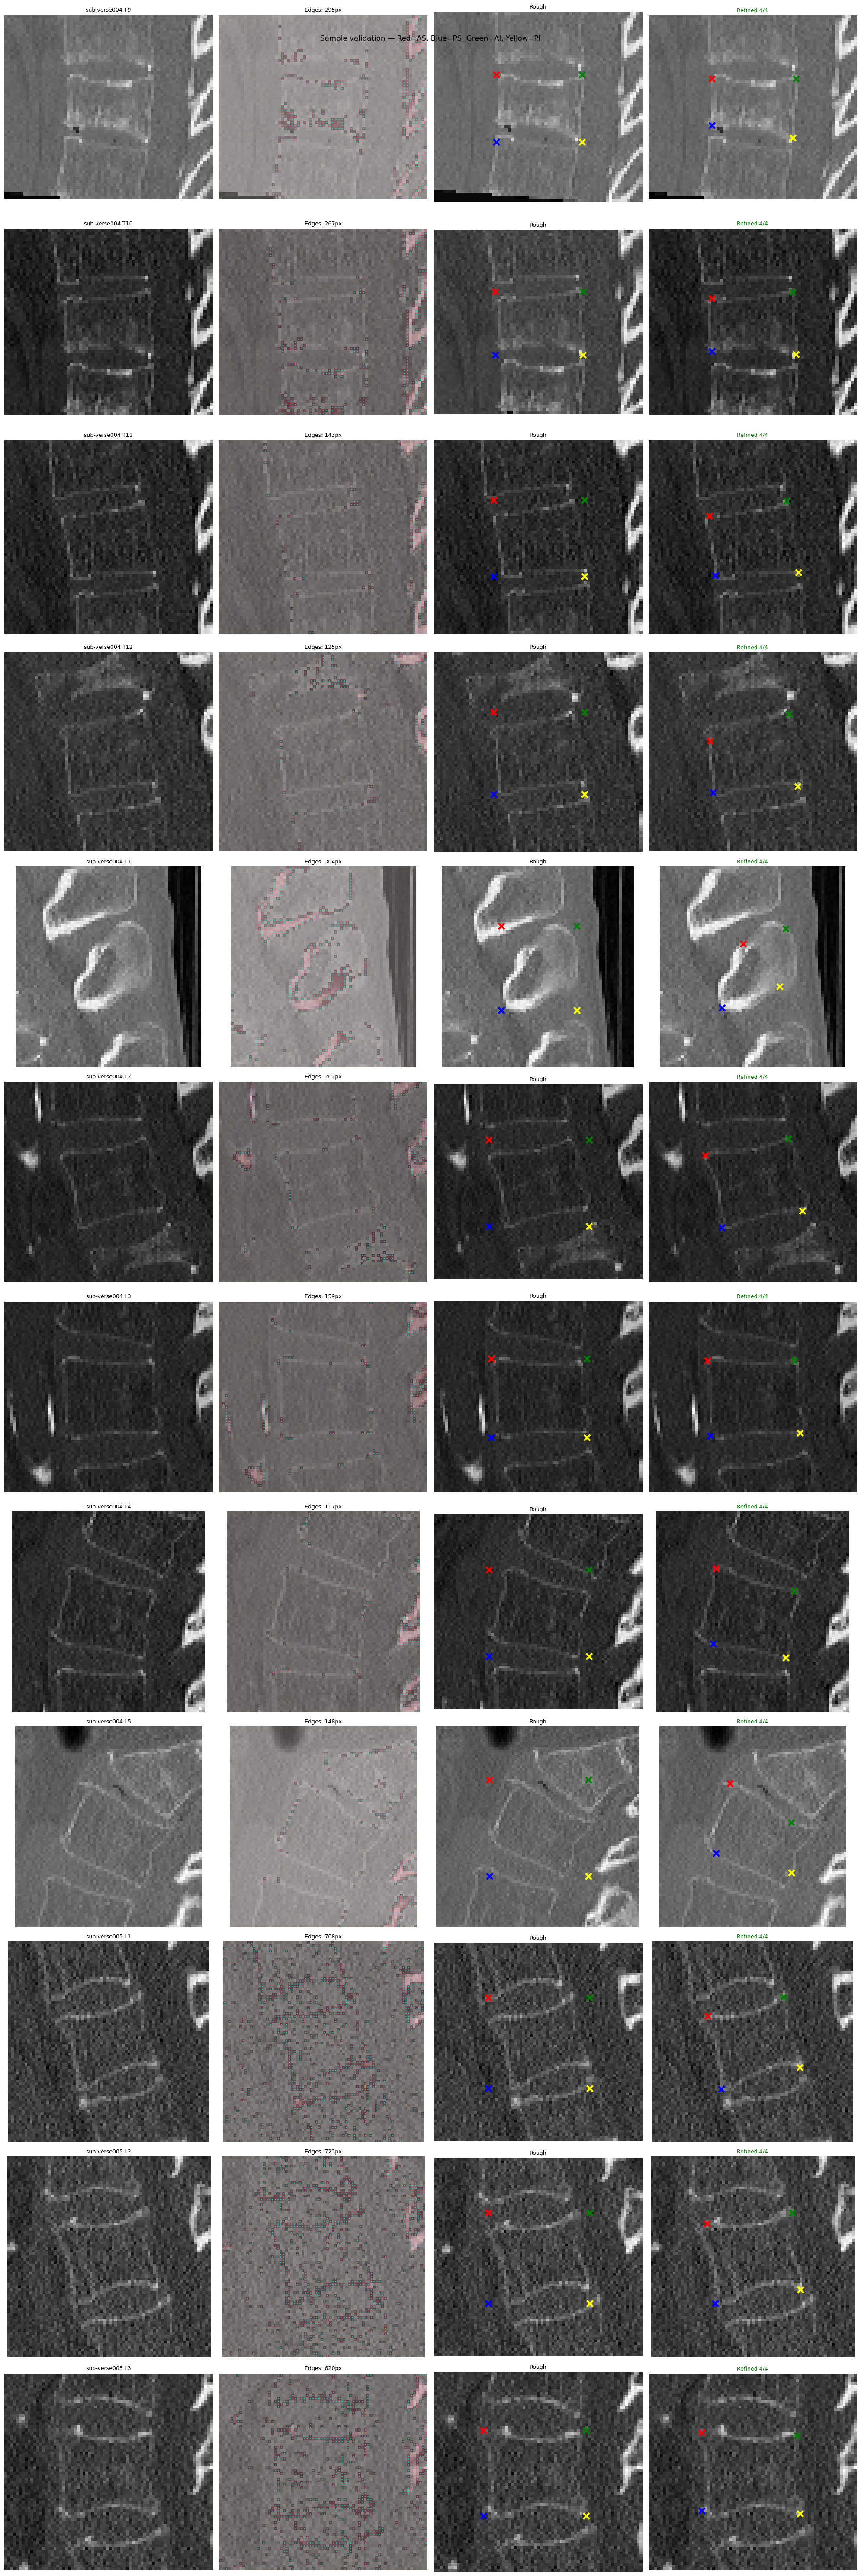


FINAL SUMMARY:
   Success rate: 369/369 (100.0%)
   Out of bounds: 0/369
   Mean corner movement: 6.0px
   All checks passed - ready to proceed


In [10]:
# 6. Validate Extracted Data
import matplotlib.pyplot as plt
from scipy import ndimage

# flatten corners for validation
all_entries = []
for subject in training_data:
    for label, data in subject['corners'].items():
        all_entries.append({
            'subject_id':      subject['subject_id'],
            'vertebra_name':   data['name'],
            'vertebra_label':  label,
            'image':           subject['image'],
            'corners':         data['corners'],
            'corners_rough':   data['corners_rough'],
        })

print(f"Total vertebrae to validate: {len(all_entries)}")

# 1. dataset statistics
print("\n1. DATASET STATISTICS:")
from collections import Counter
name_counts = Counter(e['vertebra_name'] for e in all_entries)
for name, count in sorted(name_counts.items()):
    print(f"   {name}: {count}")

# 2. duplicate corner check
print("\n2. DUPLICATE CORNER CHECK:")
duplicates = []
successes  = []

for entry in all_entries:
    unique_count = len(np.unique(entry['corners'], axis=0))
    if unique_count < 4:
        duplicates.append(entry)
    else:
        successes.append(entry)

print(f"   Successes: {len(successes)}/{len(all_entries)}")
print(f"   Duplicates: {len(duplicates)}/{len(all_entries)}")

if duplicates:
    corner_names = ['AS', 'PS', 'AI', 'PI']
    for entry in duplicates:
        corners   = entry['corners']
        dup_pairs = []
        for i in range(4):
            for j in range(i+1, 4):
                if np.array_equal(corners[i], corners[j]):
                    dup_pairs.append(f"{corner_names[i]}-{corner_names[j]}")
        print(f"   {entry['subject_id']} {entry['vertebra_name']}: {', '.join(dup_pairs)}")

# 3. bounds check
print("\n3. CORNER BOUNDS CHECK:")
out_of_bounds = []
for entry in all_entries:
    h, w     = entry['image'].shape
    corners  = entry['corners']
    if any(c[0] < 0 or c[0] >= h or c[1] < 0 or c[1] >= w for c in corners):
        out_of_bounds.append(entry)

print(f"   Out of bounds: {len(out_of_bounds)}/{len(all_entries)}")
if not out_of_bounds:
    print("   All corners within image bounds")

# 4. corner movement analysis
print("\n4. CORNER REFINEMENT ANALYSIS:")
movements = np.array([
    np.linalg.norm(entry['corners'][i] - entry['corners_rough'][i])
    for entry in all_entries
    for i in range(4)
])
print(f"   Mean:   {movements.mean():.2f} px")
print(f"   Median: {np.median(movements):.2f} px")
print(f"   Max:    {movements.max():.2f} px")
print(f"   Std:    {movements.std():.2f} px")
large = np.sum(movements > 20)
print(f"   Large movements (>20px): {large}/{len(movements)} ({100*large/len(movements):.1f}%)")

# 5. visualise sample of examples
print("\n5. VISUALISING SAMPLE (12 examples)...")

sample = all_entries[:12]
fig, axes = plt.subplots(len(sample), 4, figsize=(20, 5 * len(sample)))
if len(sample) == 1:
    axes = axes.reshape(1, -1)

def plot_vertebra(ax, ct, corners, title, color='green'):
    y_min = max(0, int(corners[:, 0].min()) - 20)
    y_max = min(ct.shape[0], int(corners[:, 0].max()) + 20)
    z_min = max(0, int(corners[:, 1].min()) - 20)
    z_max = min(ct.shape[1], int(corners[:, 1].max()) + 20)
    crop = ct[y_min:y_max, z_min:z_max]
    ax.imshow(crop, cmap='gray')
    adj = corners.copy().astype(float)
    adj[:, 0] -= y_min
    adj[:, 1] -= z_min
    ax.scatter(adj[:, 1], adj[:, 0],
               c=['red', 'blue', 'green', 'yellow'], s=100, marker='x', linewidths=3)
    ax.set_title(title, fontsize=9, color=color)
    ax.axis('off')

for row, entry in enumerate(sample):
    ct    = entry['image']
    rough = entry['corners_rough']
    ref   = entry['corners']

    ct_norm     = (ct - ct.min()) / (ct.max() - ct.min() + 1e-8)
    bone_mask   = ct_norm > 0.5
    eroded      = ndimage.binary_erosion(bone_mask)
    edge_pixels = bone_mask & ~eroded
    edge_coords = np.argwhere(edge_pixels)
    unique_ref  = len(np.unique(ref, axis=0))

    y_min = max(0, int(ref[:, 0].min()) - 20)
    y_max = min(ct.shape[0], int(ref[:, 0].max()) + 20)
    z_min = max(0, int(ref[:, 1].min()) - 20)
    z_max = min(ct.shape[1], int(ref[:, 1].max()) + 20)
    ct_crop = ct[y_min:y_max, z_min:z_max]
    bm_crop = bone_mask[y_min:y_max, z_min:z_max]

    edge_in_crop = edge_coords[
        (edge_coords[:, 0] >= y_min) & (edge_coords[:, 0] < y_max) &
        (edge_coords[:, 1] >= z_min) & (edge_coords[:, 1] < z_max)
    ]

    axes[row, 0].imshow(ct_crop, cmap='gray')
    axes[row, 0].set_title(f"{entry['subject_id']} {entry['vertebra_name']}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(ct_crop, cmap='gray')
    axes[row, 1].imshow(bm_crop, cmap='Reds', alpha=0.3)
    if len(edge_in_crop):
        axes[row, 1].scatter(edge_in_crop[:, 1] - z_min, edge_in_crop[:, 0] - y_min,
                             c='cyan', s=1, alpha=0.5)
    axes[row, 1].set_title(f'Edges: {len(edge_in_crop)}px', fontsize=9)
    axes[row, 1].axis('off')

    plot_vertebra(axes[row, 2], ct, rough, 'Rough', color='black')

    title_color = 'green' if unique_ref == 4 else 'red'
    plot_vertebra(axes[row, 3], ct, ref, f'Refined {unique_ref}/4', color=title_color)

plt.suptitle('Sample validation — Red=AS, Blue=PS, Green=AI, Yellow=PI', fontsize=12)
plt.tight_layout()
plt.show()

# 6. summary
print("\nFINAL SUMMARY:")
print(f"   Success rate: {len(successes)}/{len(all_entries)} ({100*len(successes)/len(all_entries):.1f}%)")
print(f"   Out of bounds: {len(out_of_bounds)}/{len(all_entries)}")
print(f"   Mean corner movement: {movements.mean():.1f}px")

if not duplicates and not out_of_bounds:
    print("   All checks passed - ready to proceed")
else:
    print(f"   {len(duplicates) + len(out_of_bounds)} issues remaining")

## 7. SpineDataset & DataLoaders

In [11]:
# 7. SpineDataset (coord-aware augmentation + lumbar outputs + centroid targets)
import torch
from torch.utils.data import Dataset
import cv2

# L1-L5 label integers in order; indices into 25-slot presence/coord arrays
LUMBAR_LABEL_ORDER  = [20, 21, 22, 23, 24]            # L1..L5
LUMBAR_LABEL_NAMES  = ['L1', 'L2', 'L3', 'L4', 'L5']


class SpineDataset(Dataset):
    """
    Whole-spine dataset for CNN1 (vertebra identification)
    and CNN2 (L1-L5 corner localization + centroid aux) — Step I of the paper.

    Outputs per sample:
      image             (1, H, W)   — normalized CT slice
      presence          (25,)       — full presence vector for CNN1
      coords            (25, 4, 2)  — full 25-vertebra corners ([-1,1]) for reference
      lumbar_coords     (5, 4, 2)   — L1-L5 corners ([-1,1]) for CNN2 main loss
      lumbar_presence   (5,)        — L1-L5 presence mask for CNN2 loss
      lumbar_centroids  (5, 2)      — L1-L5 mask centroids ([-1,1]) for CNN2 aux loss
    """

    def __init__(self, data, image_size=(1024, 1024), augment=False):
        self.image_size = image_size
        self.augment    = augment

        self.samples = []
        for subject in data:
            self.samples.append({
                'subject_id': subject['subject_id'],
                'image':      subject['image'],
                'presence':   subject['presence'],
                'corners':    subject['corners'],
            })

    def __len__(self):
        return len(self.samples)

    def elastic_transform(self, image, alpha=50, sigma=5):
        from scipy.ndimage import gaussian_filter, map_coordinates
        h, w   = image.shape
        dx     = gaussian_filter(np.random.randn(h, w), sigma) * alpha
        dy     = gaussian_filter(np.random.randn(h, w), sigma) * alpha
        x, y   = np.meshgrid(np.arange(w), np.arange(h))
        coords = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))
        return map_coordinates(image, coords, order=1).reshape(h, w).astype(np.float32)

    def augment_with_coords(self, image, coords_px, extra_pts=None):
        """
        Apply geometric augmentation to image AND pixel-space coordinates together.
        Appearance-only augmentation (noise, brightness) applied to image alone.

        coords_px : (V, 4, 2) float32 in resized pixel space [y, z]
        extra_pts : (N, 2)    optional extra points (e.g. centroids) to transform
        Returns   : (image, coords_px[, extra_pts])
        """
        H, W   = image.shape
        coords = coords_px.copy()
        extra  = extra_pts.copy() if extra_pts is not None else None

        # 1. Horizontal flip (50%) — flip z, y unchanged
        if np.random.rand() > 0.5:
            image           = np.fliplr(image).copy()
            coords[:, :, 1] = (W - 1) - coords[:, :, 1]
            if extra is not None:
                extra[:, 1] = (W - 1) - extra[:, 1]

        # 2. Random rotation [-15, 15] — same matrix applied to all coords
        angle  = np.random.uniform(-15, 15)
        cy, cz = H / 2.0, W / 2.0
        M = cv2.getRotationMatrix2D((cz, cy), angle, 1.0)
        image = cv2.warpAffine(image, M, (W, H),
                               flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REFLECT)

        # transform main coords: [y, z] -> homogeneous [z, y, 1] -> M -> [z', y']
        orig_shape = coords.shape
        flat = coords.reshape(-1, 2)
        pts  = np.column_stack([flat[:, 1], flat[:, 0], np.ones(len(flat))])
        t    = (M @ pts.T).T
        coords = np.column_stack([t[:, 1], t[:, 0]]).reshape(orig_shape)

        # transform extra_pts the same way
        if extra is not None:
            pts_e  = np.column_stack([extra[:, 1], extra[:, 0], np.ones(len(extra))])
            t_e    = (M @ pts_e.T).T
            extra  = np.column_stack([t_e[:, 1], t_e[:, 0]])

        # 3. Elastic transform — image only
        if np.random.rand() > 0.5:
            image = self.elastic_transform(image, alpha=50, sigma=5)

        # 4. Gaussian noise — image only
        image = np.clip(image + np.random.normal(0, 0.01, image.shape).astype(np.float32), 0, 1)

        # 5. Brightness shift — image only
        image = np.clip(image * np.random.uniform(0.9, 1.1), 0, 1)

        if extra_pts is not None:
            return image, coords, extra
        return image, coords

    def __getitem__(self, idx):
        sample       = self.samples[idx]
        ct           = sample['image'].astype(np.float32)
        orig_shape   = ct.shape
        H_new, W_new = self.image_size

        # HU normalisation
        ct = np.clip(ct, -1000, 2000)
        ct = (ct - ct.min()) / (ct.max() - ct.min() + 1e-8)

        # Resize to target resolution
        ct_resized = cv2.resize(ct, (W_new, H_new), interpolation=cv2.INTER_LINEAR)

        scale_y = H_new / orig_shape[0]
        scale_z = W_new / orig_shape[1]

        # Build full 25-vertebra coords in resized pixel space
        coords_px = np.zeros((len(VERTEBRA_LABELS), NUM_CORNERS, 2), dtype=np.float32)
        for label, data in sample['corners'].items():
            idx_v            = LABEL_TO_IDX[label]
            c                = data['corners'].copy().astype(np.float32)
            c[:, 0]         *= scale_y
            c[:, 1]         *= scale_z
            coords_px[idx_v] = c

        # Build L1-L5 centroid targets in resized pixel space (5, 2)
        lumbar_centroids_px = np.zeros((5, 2), dtype=np.float32)
        for i, label in enumerate(LUMBAR_LABEL_ORDER):
            if label in sample['corners']:
                c = sample['corners'][label].get('centroid')
                if c is not None:
                    lumbar_centroids_px[i, 0] = c[0] * scale_y
                    lumbar_centroids_px[i, 1] = c[1] * scale_z

        # Augment image + all coords (including centroids) together
        if self.augment:
            ct_resized, coords_px, lumbar_centroids_px = self.augment_with_coords(
                ct_resized, coords_px, extra_pts=lumbar_centroids_px
            )

        # Extract L1-L5 coords and presence after (possibly augmented) coords_px
        lumbar_coords_px = np.stack(
            [coords_px[LABEL_TO_IDX[l]] for l in LUMBAR_LABEL_ORDER]
        )  # (5, 4, 2)
        lumbar_presence = np.array(
            [sample['presence'][LABEL_TO_IDX[l]] for l in LUMBAR_LABEL_ORDER],
            dtype=np.float32
        )  # (5,)

        # Normalize coords to [-1, 1] for DSNT
        def px_to_norm(px, H, W):
            n = np.zeros_like(px)
            n[..., 0] = (2 * px[..., 0] + 1) / H - 1   # y
            n[..., 1] = (2 * px[..., 1] + 1) / W - 1   # z
            return n

        coords_norm           = px_to_norm(coords_px,        H_new, W_new)   # (25, 4, 2)
        lumbar_coords_norm    = px_to_norm(lumbar_coords_px,  H_new, W_new)   # (5, 4, 2)
        lumbar_centroids_norm = np.zeros((5, 2), dtype=np.float32)
        lumbar_centroids_norm[:, 0] = (2 * lumbar_centroids_px[:, 0] + 1) / H_new - 1
        lumbar_centroids_norm[:, 1] = (2 * lumbar_centroids_px[:, 1] + 1) / W_new - 1

        return {
            'image':            torch.from_numpy(ct_resized).unsqueeze(0).float(),
            'presence':         torch.from_numpy(sample['presence'].copy()).float(),
            'coords':           torch.from_numpy(coords_norm).float(),
            'lumbar_coords':    torch.from_numpy(lumbar_coords_norm).float(),
            'lumbar_presence':  torch.from_numpy(lumbar_presence).float(),
            'lumbar_centroids': torch.from_numpy(lumbar_centroids_norm).float(),
            'subject_id':       sample['subject_id'],
        }


# create datasets
train_dataset = SpineDataset(training_data,   image_size=IMAGE_SIZE_STEP1, augment=True)
val_dataset   = SpineDataset(validation_data, image_size=IMAGE_SIZE_STEP1, augment=False)
test_dataset  = SpineDataset(test_data,       image_size=IMAGE_SIZE_STEP1, augment=False)

# sanity check
sample = train_dataset[0]
print(f"Image shape:             {sample['image'].shape}")
print(f"Presence shape:          {sample['presence'].shape}")
print(f"Coords shape:            {sample['coords'].shape}")
print(f"Lumbar coords shape:     {sample['lumbar_coords'].shape}")
print(f"Lumbar presence shape:   {sample['lumbar_presence'].shape}")
print(f"Lumbar centroids shape:  {sample['lumbar_centroids'].shape}")
print(f"Lumbar presence:         {sample['lumbar_presence'].tolist()}")
print(f"Lumbar centroids range:  [{sample['lumbar_centroids'].min():.3f}, {sample['lumbar_centroids'].max():.3f}]")
print(f"Subject:                 {sample['subject_id']}")
print(f"\nTrain: {len(train_dataset)} subjects")
print(f"Val:   {len(val_dataset)} subjects")
print(f"Test:  {len(test_dataset)} subjects")


Image shape:             torch.Size([1, 1024, 1024])
Presence shape:          torch.Size([25])
Coords shape:            torch.Size([25, 4, 2])
Lumbar coords shape:     torch.Size([5, 4, 2])
Lumbar presence shape:   torch.Size([5])
Lumbar centroids shape:  torch.Size([5, 2])
Lumbar presence:         [1.0, 1.0, 1.0, 1.0, 1.0]
Lumbar centroids range:  [-0.513, 0.298]
Subject:                 sub-verse004

Train: 53 subjects
Val:   29 subjects
Test:  30 subjects


In [12]:
# 8. DataLoaders — Whole-Spine
from torch.utils.data import DataLoader
import time

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

print(f"Train: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Val:   {len(val_loader)} batches of {BATCH_SIZE}")
print(f"Test:  {len(test_loader)} batches of {BATCH_SIZE}")

# speed test
start = time.time()
batch = next(iter(train_loader))
elapsed = time.time() - start

print(f"\nFirst batch load time: {elapsed:.3f}s")
print(f"Image shape:    {batch['image'].shape}")
print(f"Presence shape: {batch['presence'].shape}")
print(f"Coords shape:   {batch['coords'].shape}")
print(f"Coords range:   [{batch['coords'].min():.3f}, {batch['coords'].max():.3f}]")

# estimate epoch time
start = time.time()
for i, b in enumerate(train_loader):
    if i >= 4:
        break
elapsed = time.time() - start
epoch_estimate = (elapsed / 5) * len(train_loader)
print(f"\nEstimated epoch time: {epoch_estimate:.1f}s ({epoch_estimate/60:.2f} mins)")

Train: 27 batches of 2
Val:   15 batches of 2
Test:  15 batches of 2

First batch load time: 1.727s
Image shape:    torch.Size([2, 1, 1024, 1024])
Presence shape: torch.Size([2, 25])
Coords shape:   torch.Size([2, 25, 4, 2])
Coords range:   [-0.920, 1.143]

Estimated epoch time: 9.4s (0.16 mins)


## 8. Model Definitions

In [13]:
# 9. CNN1 — Vertebra Identification (ResNet50)
import torchvision.models as models
import torch.nn as nn

class CNN1(nn.Module):
    """
    Vertebra identification network.
    Paper: ResNet50 pretrained on ImageNet, transfer learning,
           weights frozen up to Bottleneck block 3,
           final FC replaced with 24-neuron output (we use 25).
           Multi-label binary classification — sigmoid + BCE loss.
    Input:  (B, 1, 1024, 1024)
    Output: (B, 25) binary presence vector
    """

    def __init__(self, num_vertebrae=25):
        super().__init__()

        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # paper: input is greyscale (1 channel) not RGB (3 channel)
        # replace first conv to accept 1 channel
        # keep pretrained weights by averaging across RGB channels
        old_conv   = backbone.conv1
        new_conv   = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = new_conv

        # paper: freeze weights up to Bottleneck block 3
        frozen = [backbone.conv1, backbone.bn1, backbone.layer1,
                  backbone.layer2, backbone.layer3]
        for layer in frozen:
            for param in layer.parameters():
                param.requires_grad = False

        # keep everything up to avgpool
        self.backbone = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
            backbone.avgpool,
        )

        # paper: replace FC with num_vertebrae output neurons
        self.fc = nn.Linear(2048, num_vertebrae)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x  # raw logits — BCEWithLogitsLoss handles sigmoid


# instantiate and verify
cnn1 = CNN1(num_vertebrae=len(VERTEBRA_LABELS)).to(device)

# parameter count
total_params    = sum(p.numel() for p in cnn1.parameters())
trainable_params = sum(p.numel() for p in cnn1.parameters() if p.requires_grad)
print(f"CNN1 (ResNet50):")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Frozen params:    {total_params - trainable_params:,}")

# forward pass test
with torch.no_grad():
    dummy  = torch.randn(2, 1, 1024, 1024).to(device)
    output = cnn1(dummy)
    print(f"\nForward pass:")
    print(f"  Input:  {dummy.shape}")
    print(f"  Output: {output.shape}")
    print(f"  Expected: (2, {len(VERTEBRA_LABELS)})")

CNN1 (ResNet50):
  Total params:     23,552,985
  Trainable params: 15,015,961
  Frozen params:    8,537,024

Forward pass:
  Input:  torch.Size([2, 1, 1024, 1024])
  Output: torch.Size([2, 25])
  Expected: (2, 25)


In [14]:
# 10. CNN2 — L1-L5 Corner Localisation (InceptionV3 + DSNT, 5 vertebrae)
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

def dsnt(heatmaps):
    """
    Differentiable Spatial to Numerical Transform.
    Converts spatial heatmaps to normalized coordinates via softmax + expected value.

    Args:
        heatmaps: (B, V, C, H, W)
    Returns:
        coords: (B, V, C, 2) in [-1, 1]  — (y, z)
    """
    B, V, C, H, W = heatmaps.shape
    heatmaps = heatmaps.view(B, V, C, -1)
    heatmaps = F.softmax(heatmaps, dim=-1)
    heatmaps = heatmaps.view(B, V, C, H, W)
    xs = torch.linspace(-1, 1, W, device=heatmaps.device)
    ys = torch.linspace(-1, 1, H, device=heatmaps.device)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    x_coords = (heatmaps * grid_x).sum(dim=[-2, -1])
    y_coords = (heatmaps * grid_y).sum(dim=[-2, -1])
    return torch.stack([y_coords, x_coords], dim=-1)


class CNN2(nn.Module):
    """
    InceptionV3-based whole-image corner localisation for L1-L5 only (5 vertebrae).

    Outputs:
      coords_main    (B, 5, 4, 2) — DSNT corner predictions, [-1,1]
      coords_aux     (B, 5, 4, 2) — direct regression aux corners (training only)
      centroid_pred  (B, 5, 2)    — centroid predictions for aux supervision (training only)
    """
    def __init__(self, num_vertebrae=5, num_corners=4):
        super().__init__()
        self.num_vertebrae = num_vertebrae
        self.num_corners   = num_corners

        backbone = models.inception_v3(
            weights=models.Inception_V3_Weights.IMAGENET1K_V1,
            aux_logits=True,
            transform_input=False
        )

        # replace first conv to accept 1-channel CT input
        old_conv = backbone.Conv2d_1a_3x3.conv
        new_conv = nn.Conv2d(1, 32, kernel_size=3, stride=2, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.Conv2d_1a_3x3.conv = new_conv

        # freeze up to Mixed_6 (train only Mixed_7 + heads)
        for name, param in backbone.named_parameters():
            if not any(layer in name for layer in ['Mixed_7', 'fc', 'AuxLogits']):
                param.requires_grad = False

        self.features = nn.Sequential(
            backbone.Conv2d_1a_3x3, backbone.Conv2d_2a_3x3, backbone.Conv2d_2b_3x3,
            backbone.maxpool1,      backbone.Conv2d_3b_1x1,  backbone.Conv2d_4a_3x3,
            backbone.maxpool2,
            backbone.Mixed_5b, backbone.Mixed_5c, backbone.Mixed_5d,
            backbone.Mixed_6a, backbone.Mixed_6b, backbone.Mixed_6c,
            backbone.Mixed_6d, backbone.Mixed_6e,
        )

        self.features2 = nn.Sequential(
            backbone.Mixed_7a, backbone.Mixed_7b, backbone.Mixed_7c,
        )

        # main DSNT head: (B, 2048, H, W) -> (B, V*C, H, W) heatmaps
        self.heatmap_head = nn.Conv2d(2048, num_vertebrae * num_corners, kernel_size=1)

        # auxiliary branches from InceptionV3 AuxLogits pool -> (B, 768) after Identity fc
        self.aux_branch = backbone.AuxLogits
        self.aux_branch.fc = nn.Identity()

        # direct corner regression: (B, 768) -> (B, V*C*2), tanh -> [-1,1]
        self.aux_head      = nn.Linear(768, num_vertebrae * num_corners * 2)

        # centroid regression: (B, 768) -> (B, V*2), tanh -> [-1,1]
        self.centroid_head = nn.Linear(768, num_vertebrae * 2)

    def forward(self, x):
        B = x.shape[0]

        x = self.features(x)       # (B, 768, H', W')

        coords_aux    = None
        centroid_pred = None
        if self.training:
            aux_feat      = self.aux_branch(x)                          # (B, 768)
            # corner aux
            aux_out       = self.aux_head(aux_feat)                     # (B, V*C*2)
            coords_aux    = torch.tanh(aux_out).view(B, self.num_vertebrae, self.num_corners, 2)
            # centroid aux
            cent_out      = self.centroid_head(aux_feat)                # (B, V*2)
            centroid_pred = torch.tanh(cent_out).view(B, self.num_vertebrae, 2)

        x           = self.features2(x)                                 # (B, 2048, H'', W'')
        heatmaps    = self.heatmap_head(x)                              # (B, V*C, H'', W'')
        H, W        = heatmaps.shape[-2:]
        heatmaps    = heatmaps.view(B, self.num_vertebrae, self.num_corners, H, W)
        coords_main = dsnt(heatmaps)                                    # (B, 5, 4, 2)

        return coords_main, coords_aux, centroid_pred


# instantiate and verify shape
cnn2 = CNN2(num_vertebrae=5, num_corners=NUM_CORNERS).to(device)

total_params     = sum(p.numel() for p in cnn2.parameters())
trainable_params = sum(p.numel() for p in cnn2.parameters() if p.requires_grad)
print(f"CNN2 (InceptionV3 + DSNT, L1-L5 only):")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Frozen params:    {total_params - trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 1, 1024, 1024).to(device)
    cnn2.eval()
    coords_main, _, _ = cnn2(dummy)
    print(f"\nForward pass (eval mode):")
    print(f"  Input:        {dummy.shape}")
    print(f"  Main output:  {coords_main.shape}  (expected (2, 5, 4, 2))")
    print(f"  Coords range: [{coords_main.min():.3f}, {coords_main.max():.3f}]")


CNN2 (InceptionV3 + DSNT, L1-L5 only):
  Total params:     24,422,118
  Trainable params: 15,456,838
  Frozen params:    8,965,280

Forward pass (eval mode):
  Input:        torch.Size([2, 1, 1024, 1024])
  Main output:  torch.Size([2, 5, 4, 2])  (expected (2, 5, 4, 2))
  Coords range: [-0.030, 0.019]


In [15]:
# 11. CNN3 — Single-Vertebra Refinement (InceptionV3 + DSNT)
class CNN3(nn.Module):
    """
    Single vertebra corner refinement network.
    Paper: same InceptionV3 + DSNT architecture as CNN2 but:
           - processes single vertebra crops at 512x512
           - one DSNT layer (not 25) — one vertebra at a time
           - output: (B, 1, 4, 2) normalized coordinates
    """

    def __init__(self, num_corners=4):
        super().__init__()
        self.num_corners = num_corners

        backbone = models.inception_v3(
            weights=models.Inception_V3_Weights.IMAGENET1K_V1,
            aux_logits=True,
            transform_input=False
        )

        # replace first conv for 1 channel input
        old_conv = backbone.Conv2d_1a_3x3.conv
        new_conv = nn.Conv2d(1, 32, kernel_size=3, stride=2, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.Conv2d_1a_3x3.conv = new_conv

        for name, param in backbone.named_parameters():
            if not any(layer in name for layer in ['Mixed_7', 'fc', 'AuxLogits']):
                param.requires_grad = False

        self.features = nn.Sequential(
            backbone.Conv2d_1a_3x3,
            backbone.Conv2d_2a_3x3,
            backbone.Conv2d_2b_3x3,
            backbone.maxpool1,
            backbone.Conv2d_3b_1x1,
            backbone.Conv2d_4a_3x3,
            backbone.maxpool2,
            backbone.Mixed_5b,
            backbone.Mixed_5c,
            backbone.Mixed_5d,
            backbone.Mixed_6a,
            backbone.Mixed_6b,
            backbone.Mixed_6c,
            backbone.Mixed_6d,
            backbone.Mixed_6e,
        )

        self.features2 = nn.Sequential(
            backbone.Mixed_7a,
            backbone.Mixed_7b,
            backbone.Mixed_7c,
        )

        # single DSNT head — one vertebra, 4 corners
        self.heatmap_head = nn.Conv2d(2048, num_corners, kernel_size=1)

        # auxiliary head: direct coordinate regression (same fix as CNN2)
        self.aux_branch = backbone.AuxLogits
        self.aux_branch.fc = nn.Identity()
        self.aux_head = nn.Linear(768, num_corners * 2)   # (y, z) per corner, tanh -> [-1,1]

    def forward(self, x):
        B = x.shape[0]

        x = self.features(x)

        aux_coords = None
        if self.training:
            aux_out    = self.aux_branch(x)               # (B, 768)
            aux_out    = self.aux_head(aux_out)            # (B, C*2)
            aux_coords = torch.tanh(aux_out)
            aux_coords = aux_coords.view(B, 1, self.num_corners, 2)

        x          = self.features2(x)
        heatmaps   = self.heatmap_head(x)                 # (B, 4, H, W)
        H, W       = heatmaps.shape[-2:]
        heatmaps   = heatmaps.view(B, 1, self.num_corners, H, W)
        coords     = dsnt(heatmaps)                        # (B, 1, 4, 2)

        return coords, aux_coords


# instantiate and verify
cnn3 = CNN3(num_corners=NUM_CORNERS).to(device)

total_params     = sum(p.numel() for p in cnn3.parameters())
trainable_params = sum(p.numel() for p in cnn3.parameters() if p.requires_grad)
print(f"CNN3 (InceptionV3 + DSNT - single vertebra):")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Frozen params:    {total_params - trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 1, 512, 512).to(device)
    cnn3.eval()
    coords, _ = cnn3(dummy)
    print(f"\nForward pass:")
    print(f"  Input:        {dummy.shape}")
    print(f"  Output:       {coords.shape}")
    print(f"  Expected:     (2, 1, {NUM_CORNERS}, 2)")
    print(f"  Coords range: [{coords.min():.3f}, {coords.max():.3f}]")

print(f"\nAll three models ready:")
print(f"  CNN1: {sum(p.numel() for p in cnn1.parameters() if p.requires_grad):,} trainable params")
print(f"  CNN2: {sum(p.numel() for p in cnn2.parameters() if p.requires_grad):,} trainable params")
print(f"  CNN3: {sum(p.numel() for p in cnn3.parameters() if p.requires_grad):,} trainable params")

CNN3 (InceptionV3 + DSNT - single vertebra):
  Total params:     24,357,036
  Trainable params: 15,391,756
  Frozen params:    8,965,280

Forward pass:
  Input:        torch.Size([2, 1, 512, 512])
  Output:       torch.Size([2, 1, 4, 2])
  Expected:     (2, 1, 4, 2)
  Coords range: [-0.032, 0.041]

All three models ready:
  CNN1: 15,015,961 trainable params
  CNN2: 15,456,838 trainable params
  CNN3: 15,391,756 trainable params


## 9. Loss Functions

In [16]:
# 12. Loss Functions

def bce_loss(pred, target):
    """CNN1 loss — multi-label binary classification.
    pred:   (B, 25) raw logits
    target: (B, 25) binary presence vector
    """
    return nn.BCEWithLogitsLoss()(pred, target)


def euclidean_loss(pred, target, presence):
    """
    Mean Euclidean distance between predicted and ground truth coords.
    Only present vertebrae contribute.

    pred:     (B, V, 4, 2)
    target:   (B, V, 4, 2)
    presence: (B, V)
    """
    diff = pred - target
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)   # (B, V, 4)
    mask = presence.unsqueeze(-1).expand_as(dist)        # (B, V, 4)
    return (dist * mask).sum() / (mask.sum() + 1e-8)


def centroid_loss(centroid_pred, centroid_target, presence):
    """
    Euclidean loss on vertebra centroid predictions.
    Easier task than corner prediction — bootstraps CNN2 learning.

    centroid_pred:   (B, V, 2)
    centroid_target: (B, V, 2)
    presence:        (B, V)
    """
    diff = centroid_pred - centroid_target
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)   # (B, V)
    return (dist * presence).sum() / (presence.sum() + 1e-8)


def cnn2_loss(coords_main, coords_aux, centroid_pred, target, presence, centroid_target=None):
    """
    Combined CNN2 loss (L1-L5 only).
      Main:     DSNT corners       (B, 5, 4, 2)
      Aux:      direct regression  (B, 5, 4, 2) — 0.4x weight, training only
      Centroid: centroid aux       (B, 5, 2)    — 0.3x weight, training only
    """
    loss = euclidean_loss(coords_main, target, presence)
    if coords_aux is not None:
        loss = loss + 0.4 * euclidean_loss(coords_aux, target, presence)
    if centroid_pred is not None and centroid_target is not None:
        loss = loss + 0.3 * centroid_loss(centroid_pred, centroid_target, presence)
    return loss


def cnn3_loss(coords_main, coords_aux, target):
    """CNN3 loss — single vertebra, no presence mask.
    target: (B, 1, 4, 2)
    """
    diff = coords_main - target
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)
    loss = dist.mean()
    if coords_aux is not None:
        diff_aux = coords_aux - target
        dist_aux = torch.sqrt((diff_aux ** 2).sum(dim=-1) + 1e-8)
        loss     = loss + 0.4 * dist_aux.mean()
    return loss


print("Loss functions defined:")
print("  bce_loss        -> CNN1 vertebra identification")
print("  cnn2_loss       -> CNN2 L1-L5 corners (+ aux corner 0.4x + centroid 0.3x)")
print("  cnn3_loss       -> CNN3 single vertebra refinement")

# quick sanity check
B, V, C = 2, 5, NUM_CORNERS

dummy_pred   = torch.randn(B, len(VERTEBRA_LABELS))
dummy_target = torch.randint(0, 2, (B, len(VERTEBRA_LABELS))).float()
print(f"\nCNN1 loss test: {bce_loss(dummy_pred, dummy_target).item():.4f}")

dummy_presence    = torch.ones(B, V)
dummy_coords_pred = torch.randn(B, V, C, 2)
dummy_coords_gt   = torch.randn(B, V, C, 2)
dummy_centroids   = torch.randn(B, V, 2)
loss2 = cnn2_loss(dummy_coords_pred, dummy_coords_pred, dummy_centroids,
                  dummy_coords_gt, dummy_presence, dummy_centroids)
print(f"CNN2 loss test: {loss2.item():.4f}")

dummy_single_pred = torch.randn(B, 1, C, 2)
dummy_single_gt   = torch.randn(B, 1, C, 2)
print(f"CNN3 loss test: {cnn3_loss(dummy_single_pred, None, dummy_single_gt).item():.4f}")


Loss functions defined:
  bce_loss        -> CNN1 vertebra identification
  cnn2_loss       -> CNN2 L1-L5 corners (+ aux corner 0.4x + centroid 0.3x)
  cnn3_loss       -> CNN3 single vertebra refinement

CNN1 loss test: 0.8233
CNN2 loss test: 2.5000
CNN3 loss test: 1.9463


## 10. Training Loops

In [17]:
# 13. Training Loops
import os

def train_cnn1(model, train_loader, val_loader, num_epochs, lr, save_path):
    """CNN1 — vertebra identification.
    Paper: lr=0.0001, batch=16, 200 epochs, ReduceLROnPlateau patience=10
    """
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=LR_REDUCE_FACTOR, patience=EARLY_STOP_PATIENCE
    )
    best_val_loss = float('inf')
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            images   = batch['image'].to(device)
            presence = batch['presence'].to(device)
            optimizer.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    pred = model(images)
                    loss = bce_loss(pred, presence)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            else:
                pred = model(images)
                loss = bce_loss(pred, presence)
                loss.backward(); optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                pred     = model(batch['image'].to(device))
                val_loss += bce_loss(pred, batch['presence'].to(device)).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.6f}")

    print(f"  Best val loss: {best_val_loss:.4f}")
    return history


def train_cnn2(model, train_loader, val_loader, num_epochs, lr, save_path):
    """
    CNN2 — L1-L5 corner localization with centroid auxiliary supervision.

    Fixes vs previous run:
      Fix 1: CosineAnnealingLR — prevents LR dying to ~0 by epoch 70
      Fix 2: L1-L5 only (5 vertebrae) — easier task, less noise from unseen vertebrae
      Fix 3: Centroid auxiliary head — bootstraps spatial learning on easier task

    Paper: lr=0.001, batch=8, 200 epochs.
    Gradient accumulation over GRAD_ACCUM_STEPS to match effective batch size.
    """
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    # CosineAnnealingLR: smooth cosine decay from lr -> eta_min over all epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=lr * 0.01)

    best_val_loss = float('inf')
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            images    = batch['image'].to(device)
            presence  = batch['lumbar_presence'].to(device)    # (B, 5)
            coords    = batch['lumbar_coords'].to(device)       # (B, 5, 4, 2)
            centroids = batch['lumbar_centroids'].to(device)    # (B, 5, 2)

            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    coords_main, coords_aux, centroid_pred = model(images)
                    loss = cnn2_loss(coords_main, coords_aux, centroid_pred,
                                     coords, presence, centroids)
                    loss = loss / GRAD_ACCUM_STEPS
                scaler.scale(loss).backward()
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                    scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            else:
                coords_main, coords_aux, centroid_pred = model(images)
                loss = cnn2_loss(coords_main, coords_aux, centroid_pred,
                                  coords, presence, centroids)
                loss = loss / GRAD_ACCUM_STEPS
                loss.backward()
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                    optimizer.step(); optimizer.zero_grad()

            train_loss += loss.item() * GRAD_ACCUM_STEPS

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images   = batch['image'].to(device)
                presence = batch['lumbar_presence'].to(device)
                coords   = batch['lumbar_coords'].to(device)
                coords_main, _, _ = model(images)
                val_loss += cnn2_loss(coords_main, None, None, coords, presence).item()
        val_loss /= len(val_loader)

        scheduler.step()   # CosineAnnealingLR: step per epoch, no val_loss argument
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.6f}")

    print(f"  Best val loss: {best_val_loss:.4f}")
    return history


def train_cnn3(model, train_loader, val_loader, num_epochs, lr, save_path):
    """CNN3 — single vertebra refinement.
    Paper: lr=0.0001, batch=16, 200 epochs, ReduceLROnPlateau patience=10
    """
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=LR_REDUCE_FACTOR, patience=EARLY_STOP_PATIENCE
    )
    best_val_loss = float('inf')
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            images = batch['image'].to(device)
            coords = batch['coords'].to(device)
            optimizer.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    coords_main, coords_aux = model(images)
                    loss = cnn3_loss(coords_main, coords_aux, coords)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            else:
                coords_main, coords_aux = model(images)
                loss = cnn3_loss(coords_main, coords_aux, coords)
                loss.backward(); optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                coords_main, _ = model(batch['image'].to(device))
                val_loss += cnn3_loss(coords_main, None, batch['coords'].to(device)).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.6f}")

    print(f"  Best val loss: {best_val_loss:.4f}")
    return history


print("Training functions defined:")
print("  train_cnn1 -> vertebra identification")
print("  train_cnn2 -> L1-L5 corners (CosineAnnealingLR, centroid aux, grad accum)")
print("  train_cnn3 -> single vertebra refinement")


Training functions defined:
  train_cnn1 -> vertebra identification
  train_cnn2 -> L1-L5 corners (CosineAnnealingLR, centroid aux, grad accum)
  train_cnn3 -> single vertebra refinement


## 11. CNN1 — Vertebra Identification

In [18]:
# 14. CNN1 Quick Test — 5 epochs
import torch.optim as optim

# AMP scaler
scaler = torch.amp.GradScaler('cuda') if USE_AMP and torch.cuda.is_available() else None
# override USE_AMP if no scaler
if scaler is None and USE_AMP:
    print("Warning: AMP requested but no CUDA — disabling AMP")
    USE_AMP = False

save_dir = 'H:/My Drive/Project/models'
os.makedirs(save_dir, exist_ok=True)

print("Quick training test — CNN1, 5 epochs")
print("=" * 50)

history_test = train_cnn1(
    model       = cnn1,
    train_loader= train_loader,
    val_loader  = val_loader,
    num_epochs  = 5,
    lr          = LR_CNN1,
    save_path   = os.path.join(save_dir, 'cnn1_test.pth')
)

print("\nLoss curve:")
for i, (t, v) in enumerate(zip(history_test['train_loss'],
                                history_test['val_loss'])):
    print(f"  Epoch {i+1}: train={t:.4f}  val={v:.4f}")

Quick training test — CNN1, 5 epochs
  Best val loss: 0.1758

Loss curve:
  Epoch 1: train=0.3682  val=0.2293
  Epoch 2: train=0.1663  val=0.2554
  Epoch 3: train=0.1558  val=0.1879
  Epoch 4: train=0.1362  val=0.1795
  Epoch 5: train=0.1221  val=0.1758


Training CNN1 - 200 epochs
  Epoch  10/200  train=0.1093  val=0.1893  lr=0.000100
  Epoch  20/200  train=0.0883  val=0.2261  lr=0.000010
  Epoch  30/200  train=0.0807  val=0.2598  lr=0.000001
  Epoch  40/200  train=0.0772  val=0.2344  lr=0.000000
  Epoch  50/200  train=0.0909  val=0.2463  lr=0.000000
  Epoch  60/200  train=0.0778  val=0.2606  lr=0.000000
  Epoch  70/200  train=0.0818  val=0.2444  lr=0.000000
  Epoch  80/200  train=0.0862  val=0.2505  lr=0.000000
  Epoch  90/200  train=0.0743  val=0.2468  lr=0.000000
  Epoch 100/200  train=0.0803  val=0.2293  lr=0.000000
  Epoch 110/200  train=0.0797  val=0.2317  lr=0.000000
  Epoch 120/200  train=0.0798  val=0.2424  lr=0.000000
  Epoch 130/200  train=0.0859  val=0.2690  lr=0.000000
  Epoch 140/200  train=0.0800  val=0.2549  lr=0.000000
  Epoch 150/200  train=0.0977  val=0.2393  lr=0.000000
  Epoch 160/200  train=0.0751  val=0.2671  lr=0.000000
  Epoch 170/200  train=0.0748  val=0.2669  lr=0.000000
  Epoch 180/200  train=0.0735  val=0.2

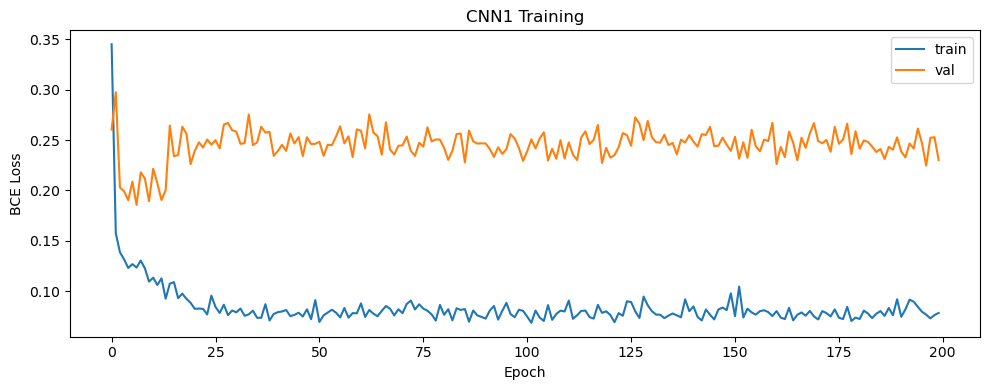

In [19]:
# 15. CNN1 Full Training — 200 epochs
import torch.optim as optim

scaler   = torch.amp.GradScaler('cuda') if USE_AMP and torch.cuda.is_available() else None
save_dir = 'H:/My Drive/Project/models'
os.makedirs(save_dir, exist_ok=True)

# reinitialise fresh model
cnn1 = CNN1(num_vertebrae=len(VERTEBRA_LABELS)).to(device)

print("Training CNN1 - 200 epochs")
print("=" * 50)

history_cnn1 = train_cnn1(
    model        = cnn1,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = NUM_EPOCHS,
    lr           = LR_CNN1,
    save_path    = os.path.join(save_dir, 'cnn1_best.pth')
)

# plot loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_cnn1['train_loss'], label='train')
ax.plot(history_cnn1['val_loss'],   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('CNN1 Training')
ax.legend()
plt.tight_layout()
plt.show()

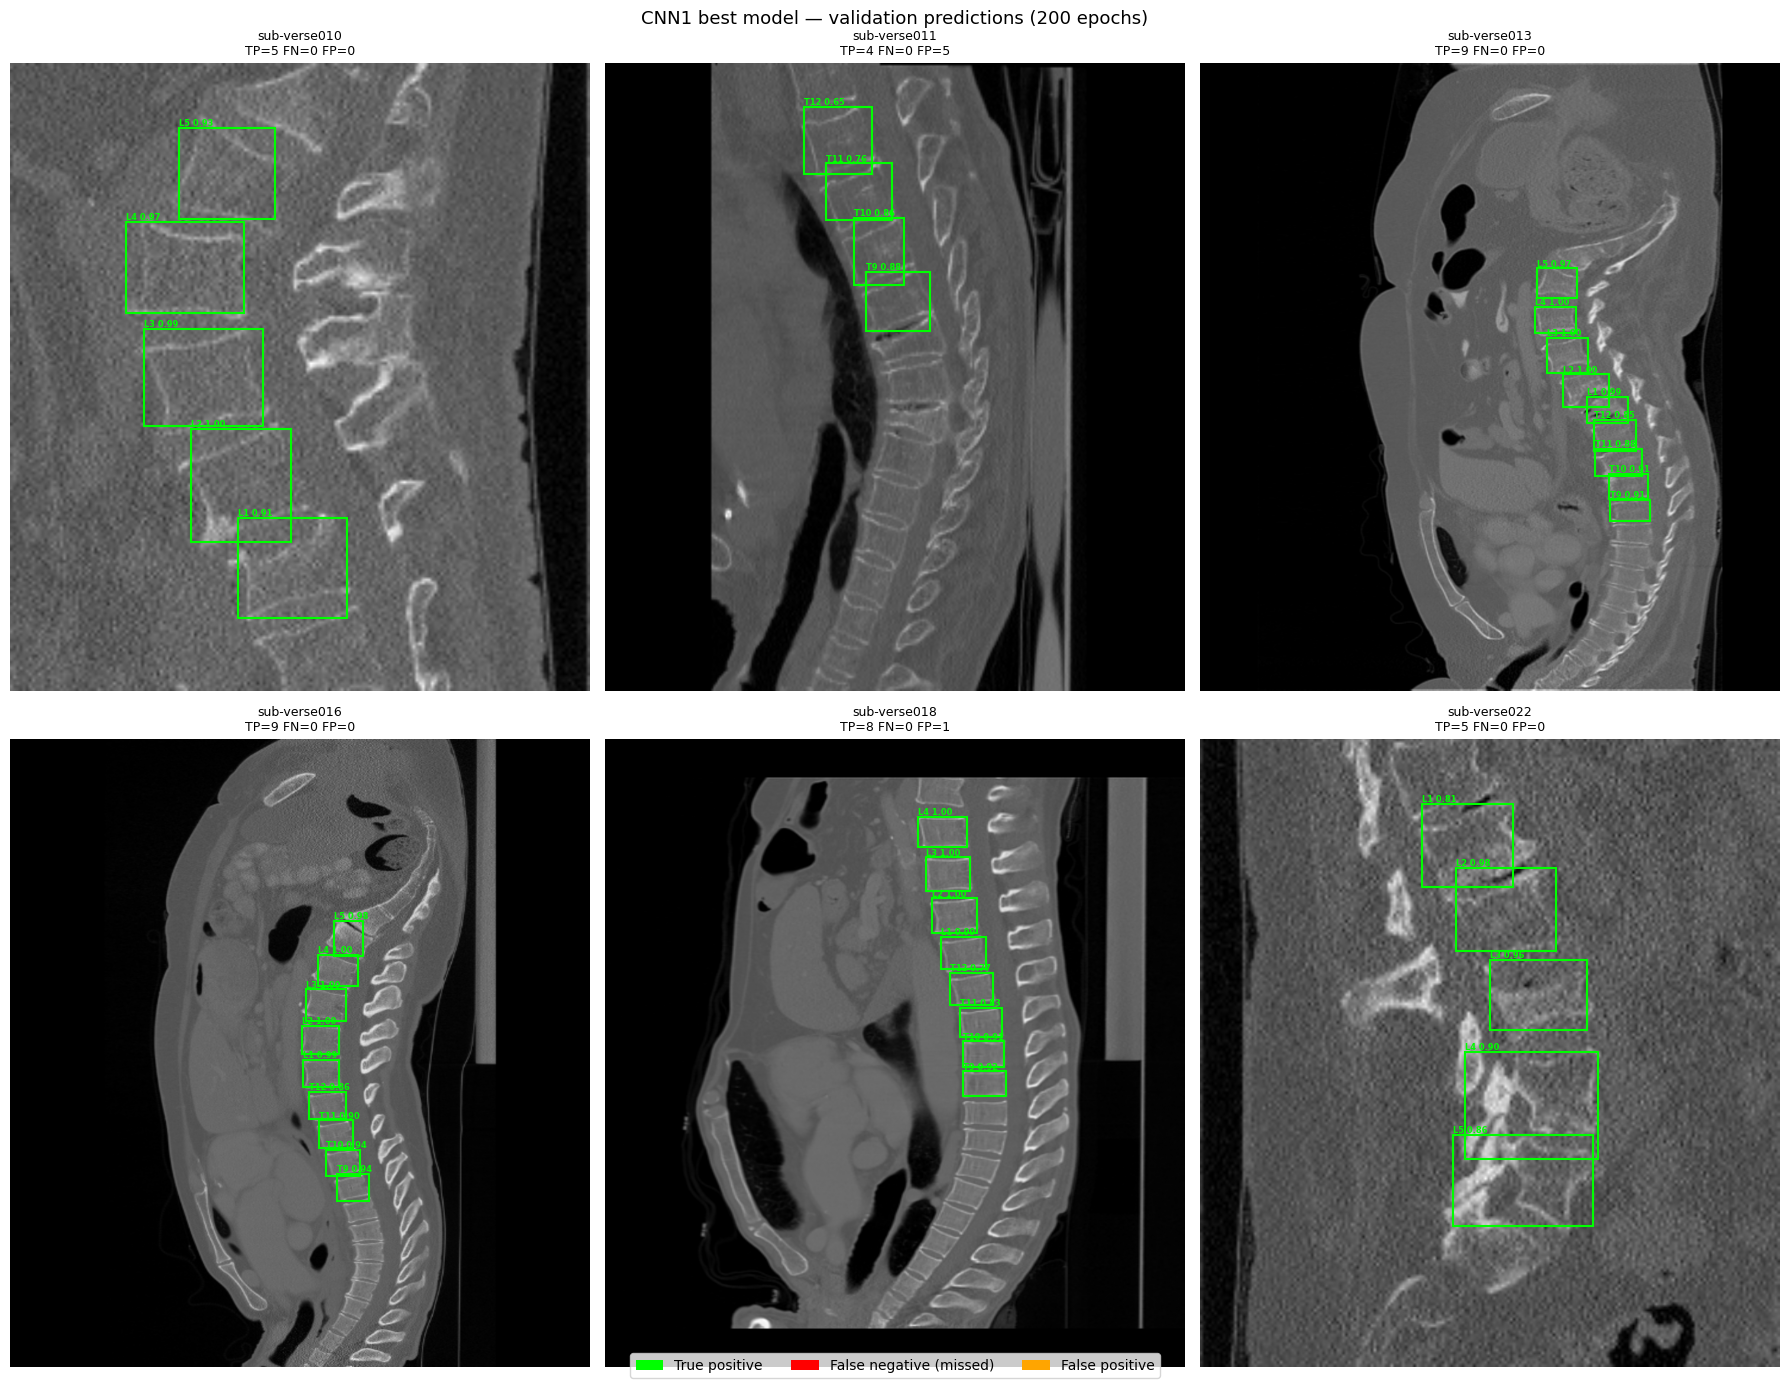

In [20]:
# 16. CNN1 Visualise Best Model

cnn1.load_state_dict(torch.load('H:/My Drive/Project/models/cnn1_best.pth',
                                 map_location=device))
cnn1.eval()

n_show = 6
shown  = 0

fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

with torch.no_grad():
    for batch in val_loader:
        images   = batch['image'].to(device)
        presence = batch['presence']
        subjects = batch['subject_id']
        preds    = torch.sigmoid(cnn1(images)).cpu()

        for i in range(len(subjects)):
            if shown >= n_show:
                break

            ax         = axes[shown]
            img        = images[i, 0].cpu().numpy()
            pred_v     = preds[i]
            gt_v       = presence[i]
            subject_id = subjects[i]

            ax.imshow(img, cmap='gray', aspect='auto')

            subject_data = next(
                (d for d in validation_data if d['subject_id'] == subject_id),
                None
            )

            if subject_data is not None:
                orig_h, orig_w = subject_data['image'].shape
                scale_y = IMAGE_SIZE_STEP1[0] / orig_h
                scale_z = IMAGE_SIZE_STEP1[1] / orig_w

                for label in sorted(VERTEBRA_LABELS.keys()):
                    idx    = LABEL_TO_IDX[label]
                    name   = VERTEBRA_LABELS[label]
                    gt     = gt_v[idx].item()
                    pred   = pred_v[idx].item()
                    binary = pred > 0.5

                    if label not in subject_data['corners']:
                        continue

                    corners = subject_data['corners'][label]['corners'].copy().astype(np.float32)
                    corners[:, 0] *= scale_y
                    corners[:, 1] *= scale_z

                    if gt == 1 and binary:
                        color = 'lime'
                    elif gt == 1 and not binary:
                        color = 'red'
                    else:
                        color = 'orange'

                    y_min = corners[:, 0].min()
                    y_max = corners[:, 0].max()
                    z_min = corners[:, 1].min()
                    z_max = corners[:, 1].max()

                    rect = plt.Rectangle(
                        (z_min, y_min), z_max - z_min, y_max - y_min,
                        linewidth=1.5, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(z_min, y_min - 3, f"{name} {pred:.2f}",
                            color=color, fontsize=6, fontweight='bold')

            tp = ((preds[i] > 0.5) & (presence[i] == 1)).sum().item()
            fn = ((preds[i] <= 0.5) & (presence[i] == 1)).sum().item()
            fp = ((preds[i] > 0.5) & (presence[i] == 0)).sum().item()
            ax.set_title(f"{subject_id}\nTP={tp} FN={fn} FP={fp}", fontsize=9)
            ax.axis('off')
            shown += 1

        if shown >= n_show:
            break

from matplotlib.patches import Patch
legend = [
    Patch(facecolor='lime',   label='True positive'),
    Patch(facecolor='red',    label='False negative (missed)'),
    Patch(facecolor='orange', label='False positive'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10)
plt.suptitle('CNN1 best model — validation predictions (200 epochs)', fontsize=13)
plt.tight_layout()
plt.show()

CNN1 VALIDATION METRICS (best model)
  Accuracy:  0.943
  Precision: 0.852
  Recall:    0.971
  F1:        0.907
  TP: 201  FP: 35  FN: 6  TN: 483

Per-vertebra metrics:
Vertebra GT_pos   TP   FP   FN   Prec    Rec     F1
--------------------------------------------------
T9           19   18    5    1   0.78   0.95   0.86
T10          19   18    5    1   0.78   0.95   0.86
T11          20   19    4    1   0.83   0.95   0.88
T12          22   19    3    3   0.86   0.86   0.86
L1           27   27    2    0   0.93   1.00   0.96
L2           26   26    3    0   0.90   1.00   0.95
L3           25   25    4    0   0.86   1.00   0.93
L4           25   25    4    0   0.86   1.00   0.93
L5           24   24    5    0   0.83   1.00   0.91


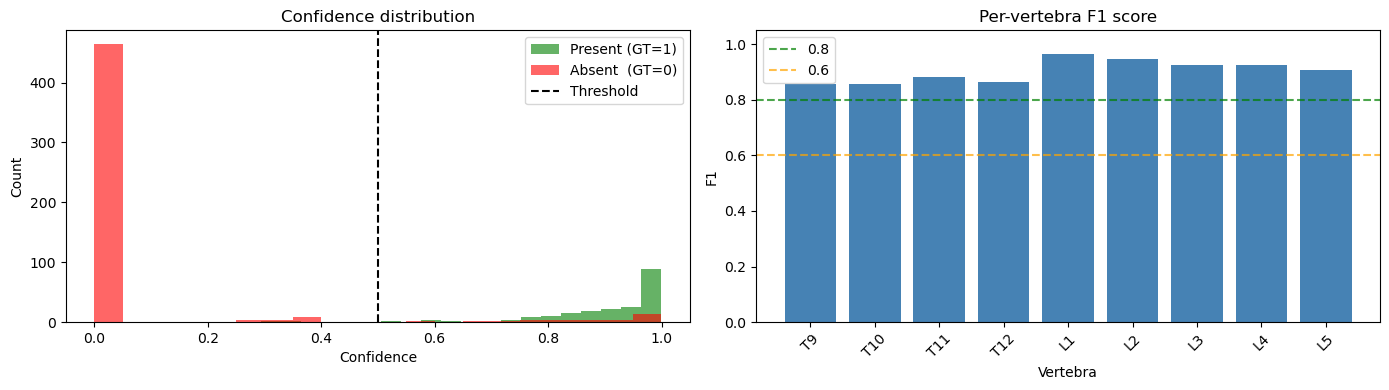

In [21]:
# 17. CNN1 Evaluation Metrics

cnn1.load_state_dict(torch.load('H:/My Drive/Project/models/cnn1_best.pth',
                                 map_location=device))
cnn1.eval()

all_preds    = []
all_targets  = []
all_subjects = []

with torch.no_grad():
    for batch in val_loader:
        images   = batch['image'].to(device)
        presence = batch['presence']
        preds    = torch.sigmoid(cnn1(images)).cpu()
        all_preds.append(preds)
        all_targets.append(presence)
        all_subjects.extend(batch['subject_id'])

all_preds   = torch.cat(all_preds,   dim=0)  # (N, 25)
all_targets = torch.cat(all_targets, dim=0)  # (N, 25)
all_binary  = (all_preds > 0.5).float()

# overall metrics
tp = (all_binary * all_targets).sum()
fp = (all_binary * (1 - all_targets)).sum()
fn = ((1 - all_binary) * all_targets).sum()
tn = ((1 - all_binary) * (1 - all_targets)).sum()

precision = tp / (tp + fp + 1e-8)
recall    = tp / (tp + fn + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)
accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-8)

print("=" * 50)
print("CNN1 VALIDATION METRICS (best model)")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  TP: {int(tp)}  FP: {int(fp)}  FN: {int(fn)}  TN: {int(tn)}")

# per vertebra breakdown
print("\nPer-vertebra metrics:")
print(f"{'Vertebra':<8} {'GT_pos':>6} {'TP':>4} {'FP':>4} {'FN':>4} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("-" * 50)

vertebra_names = [VERTEBRA_LABELS[k] for k in sorted(VERTEBRA_LABELS.keys())]
for j, name in enumerate(vertebra_names):
    gt  = all_targets[:, j]
    pred = all_binary[:, j]
    vtp = (pred * gt).sum().item()
    vfp = (pred * (1 - gt)).sum().item()
    vfn = ((1 - pred) * gt).sum().item()
    vprec = vtp / (vtp + vfp + 1e-8)
    vrec  = vtp / (vtp + vfn + 1e-8)
    vf1   = 2 * vprec * vrec / (vprec + vrec + 1e-8)
    gt_count = int(gt.sum().item())
    if gt_count > 0:  # only show vertebrae that appear in val set
        print(f"{name:<8} {gt_count:>6} {int(vtp):>4} {int(vfp):>4} {int(vfn):>4} "
              f"{vprec:>6.2f} {vrec:>6.2f} {vf1:>6.2f}")

# confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

present_conf = all_preds[all_targets == 1].numpy()
absent_conf  = all_preds[all_targets == 0].numpy()
axes[0].hist(present_conf, bins=20, alpha=0.6, color='green', label='Present (GT=1)')
axes[0].hist(absent_conf,  bins=20, alpha=0.6, color='red',   label='Absent  (GT=0)')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence distribution')
axes[0].legend()

# per vertebra F1 bar chart
vertebra_names_present = []
f1_scores = []
for j, name in enumerate(vertebra_names):
    gt  = all_targets[:, j]
    if gt.sum().item() == 0:
        continue
    pred = all_binary[:, j]
    vtp  = (pred * gt).sum().item()
    vfp  = (pred * (1 - gt)).sum().item()
    vfn  = ((1 - pred) * gt).sum().item()
    vprec = vtp / (vtp + vfp + 1e-8)
    vrec  = vtp / (vtp + vfn + 1e-8)
    vf1   = 2 * vprec * vrec / (vprec + vrec + 1e-8)
    vertebra_names_present.append(name)
    f1_scores.append(vf1)

colors = ['steelblue' if f > 0.8 else 'orange' if f > 0.6 else 'tomato' for f in f1_scores]
axes[1].bar(vertebra_names_present, f1_scores, color=colors)
axes[1].axhline(0.8, color='green',  linestyle='--', alpha=0.7, label='0.8')
axes[1].axhline(0.6, color='orange', linestyle='--', alpha=0.7, label='0.6')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Vertebra')
axes[1].set_ylabel('F1')
axes[1].set_title('Per-vertebra F1 score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. CNN2 — Whole-Image Corner Localisation

In [22]:
# 18. Vertebra Size Analysis

sizes = []
for subject in training_data:
    orig_h, orig_w = subject['image'].shape
    for label, corner_data in subject['corners'].items():
        corners = corner_data['corners'].copy().astype(np.float32)
        y_min = corners[:, 0].min()
        y_max = corners[:, 0].max()
        z_min = corners[:, 1].min()
        z_max = corners[:, 1].max()
        height_px = y_max - y_min
        width_px  = z_max - z_min
        sizes.append({
            'subject':    subject['subject_id'],
            'vertebra':   corner_data['name'],
            'height_px':  height_px,
            'width_px':   width_px,
            'img_h':      orig_h,
            'img_w':      orig_w,
        })

df_sizes = pd.DataFrame(sizes)

print("Vertebra sizes in ORIGINAL image pixel space:")
print(f"\nHeight (px):")
print(df_sizes['height_px'].describe().round(1))
print(f"\nWidth (px):")
print(df_sizes['width_px'].describe().round(1))
print(f"\nPer vertebra mean height:")
print(df_sizes.groupby('vertebra')['height_px'].mean().round(1).sort_index())
print(f"\nImage sizes:")
print(f"  Height range: {df_sizes['img_h'].min()} - {df_sizes['img_h'].max()}")
print(f"  Width range:  {df_sizes['img_w'].min()} - {df_sizes['img_w'].max()}")

Vertebra sizes in ORIGINAL image pixel space:

Height (px):
count    369.0
mean      28.8
std        5.7
min        7.0
25%       26.0
50%       28.0
75%       32.0
max       50.0
Name: height_px, dtype: float64

Width (px):
count    369.0
mean      35.4
std        8.7
min        6.0
25%       31.0
50%       34.0
75%       38.0
max       67.0
Name: width_px, dtype: float64

Per vertebra mean height:
vertebra
L1     29.600000
L2     28.400000
L3     29.700001
L4     30.100000
L5     31.700001
T10    26.100000
T11    28.000000
T12    28.600000
T9     23.400000
Name: height_px, dtype: float32

Image sizes:
  Height range: 149 - 1189
  Width range:  152 - 915


Training CNN2 - 200 epochs
  Vertebrae:  L1-L5 only (5)
  Scheduler:  CosineAnnealingLR
  Aux heads:  corner regression + centroid regression
  Epoch  10/200  train=0.5011  val=0.3387  lr=0.000994
  Epoch  20/200  train=0.4743  val=0.3427  lr=0.000976
  Epoch  30/200  train=0.4277  val=0.3511  lr=0.000946
  Epoch  40/200  train=0.3724  val=0.3434  lr=0.000905
  Epoch  50/200  train=0.3570  val=0.3367  lr=0.000855
  Epoch  60/200  train=0.3589  val=0.3392  lr=0.000796
  Epoch  70/200  train=0.3459  val=0.3413  lr=0.000730
  Epoch  80/200  train=0.2980  val=0.3333  lr=0.000658
  Epoch  90/200  train=0.3222  val=0.3194  lr=0.000582
  Epoch 100/200  train=0.2804  val=0.3217  lr=0.000505
  Epoch 110/200  train=0.2863  val=0.3242  lr=0.000428
  Epoch 120/200  train=0.2561  val=0.3291  lr=0.000352
  Epoch 130/200  train=0.2410  val=0.3172  lr=0.000280
  Epoch 140/200  train=0.2396  val=0.3237  lr=0.000214
  Epoch 150/200  train=0.2352  val=0.3342  lr=0.000155
  Epoch 160/200  train=0.2307  va

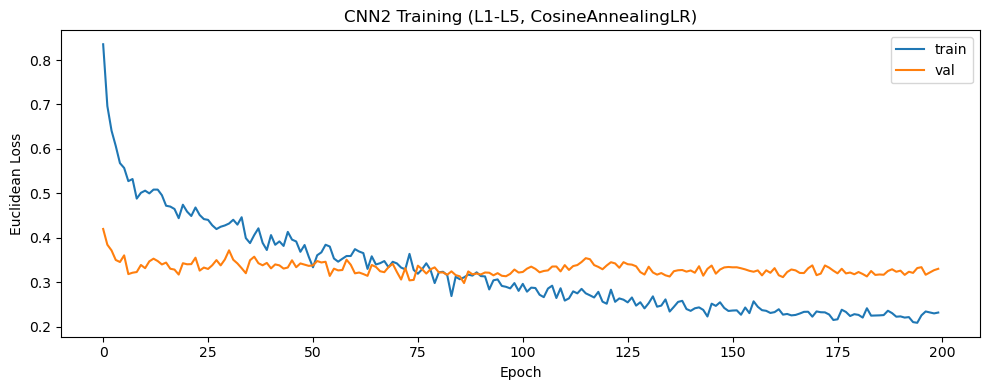

Best epoch: 87/200
Best val loss: 0.2980


In [23]:
# 19. CNN2 Full Training — 200 epochs (L1-L5, CosineAnnealingLR, centroid aux)
import torch.optim as optim

cnn2 = CNN2(num_vertebrae=5, num_corners=NUM_CORNERS).to(device)

print("Training CNN2 - 200 epochs")
print("  Vertebrae:  L1-L5 only (5)")
print("  Scheduler:  CosineAnnealingLR")
print("  Aux heads:  corner regression + centroid regression")
print("=" * 50)

history_cnn2 = train_cnn2(
    model        = cnn2,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = NUM_EPOCHS,
    lr           = LR_CNN2,
    save_path    = os.path.join(save_dir, 'cnn2_best.pth')
)

# plot loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_cnn2['train_loss'], label='train')
ax.plot(history_cnn2['val_loss'],   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Euclidean Loss')
ax.set_title('CNN2 Training (L1-L5, CosineAnnealingLR)')
ax.legend()
plt.tight_layout()
plt.show()

best_epoch = history_cnn2['val_loss'].index(min(history_cnn2['val_loss'])) + 1
print(f"Best epoch: {best_epoch}/200")
print(f"Best val loss: {min(history_cnn2['val_loss']):.4f}")


CNN2 Validation — median % error per vertebra (lower is better)
  Paper target: ~2% for lumbar vertebrae

Vertebra  Med Err X%  Med Err Y%     N
----------------------------------------
L1             45.43       94.07    27
L2             40.93       75.57    26
L3             44.72       55.64    25
L4             46.65      105.10    25
L5             46.38      102.70    24
----------------------------------------
Median         44.81       81.38


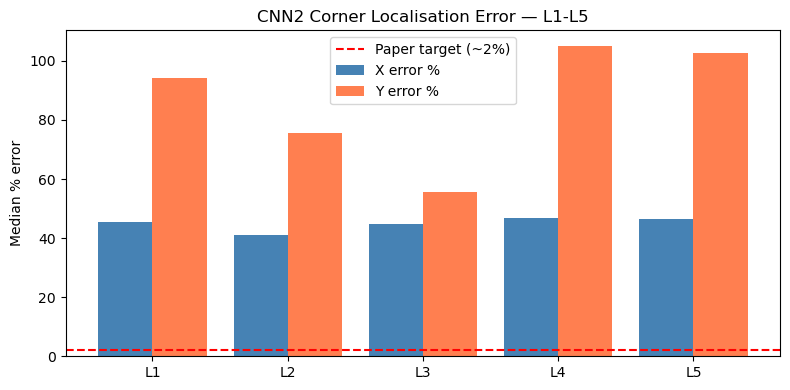

In [24]:
# 20. CNN2 Evaluation Metrics (L1-L5)
# Mirrors Table 1 from Cina et al. (2021) — median % error per vertebra

cnn2.load_state_dict(torch.load(os.path.join(save_dir, 'cnn2_best.pth'), map_location=device))
cnn2.eval()

errors_x = {name: [] for name in LUMBAR_LABEL_NAMES}
errors_y = {name: [] for name in LUMBAR_LABEL_NAMES}

with torch.no_grad():
    for batch in val_loader:
        images    = batch['image'].to(device)
        presence  = batch['lumbar_presence']      # (B, 5)
        coords_gt = batch['lumbar_coords'].numpy() # (B, 5, 4, 2)

        coords_pred, _, _ = cnn2(images)
        coords_pred = coords_pred.cpu().numpy()    # (B, 5, 4, 2)

        B = images.shape[0]
        H, W = IMAGE_SIZE_STEP1

        for b in range(B):
            for i, name in enumerate(LUMBAR_LABEL_NAMES):
                if presence[b, i] < 0.5:
                    continue
                pred = coords_pred[b, i]   # (4, 2) normalized
                gt   = coords_gt[b, i]     # (4, 2) normalized

                # back to pixel space for interpretable error
                pred_px = np.stack([(pred[:, 0] + 1) * H / 2,
                                    (pred[:, 1] + 1) * W / 2], axis=1)
                gt_px   = np.stack([(gt[:, 0]   + 1) * H / 2,
                                    (gt[:, 1]   + 1) * W / 2], axis=1)

                vert_h = gt_px[:, 0].max() - gt_px[:, 0].min()
                vert_w = gt_px[:, 1].max() - gt_px[:, 1].min()
                if vert_h < 1 or vert_w < 1:
                    continue

                for c in range(4):
                    errors_y[name].append(abs(pred_px[c, 0] - gt_px[c, 0]) / vert_h * 100)
                    errors_x[name].append(abs(pred_px[c, 1] - gt_px[c, 1]) / vert_w * 100)

print('CNN2 Validation — median % error per vertebra (lower is better)')
print(f'  Paper target: ~2% for lumbar vertebrae')
print()
print(f"{'Vertebra':<8} {'Med Err X%':>11} {'Med Err Y%':>11} {'N':>5}")
print('-' * 40)
all_x, all_y = [], []
for name in LUMBAR_LABEL_NAMES:
    ex = errors_x.get(name, [])
    ey = errors_y.get(name, [])
    if not ex:
        print(f"{name:<8} {'N/A':>11} {'N/A':>11} {'0':>5}")
        continue
    mx, my = np.median(ex), np.median(ey)
    print(f"{name:<8} {mx:>11.2f} {my:>11.2f} {len(ex)//4:>5}")
    all_x.extend(ex); all_y.extend(ey)
print('-' * 40)
if all_x:
    print(f"{'Median':<8} {np.median(all_x):>11.2f} {np.median(all_y):>11.2f}")

if all_x:
    fig, ax = plt.subplots(figsize=(8, 4))
    names_plot = LUMBAR_LABEL_NAMES
    med_x = [np.median(errors_x[n]) if errors_x[n] else 0 for n in names_plot]
    med_y = [np.median(errors_y[n]) if errors_y[n] else 0 for n in names_plot]
    x = np.arange(len(names_plot))
    ax.bar(x - 0.2, med_x, 0.4, label='X error %', color='steelblue')
    ax.bar(x + 0.2, med_y, 0.4, label='Y error %', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names_plot)
    ax.axhline(2, color='red', linestyle='--', label='Paper target (~2%)')
    ax.set_ylabel('Median % error')
    ax.set_title('CNN2 Corner Localisation Error — L1-L5')
    ax.legend(); plt.tight_layout(); plt.show()


ValueError: too many values to unpack (expected 2)

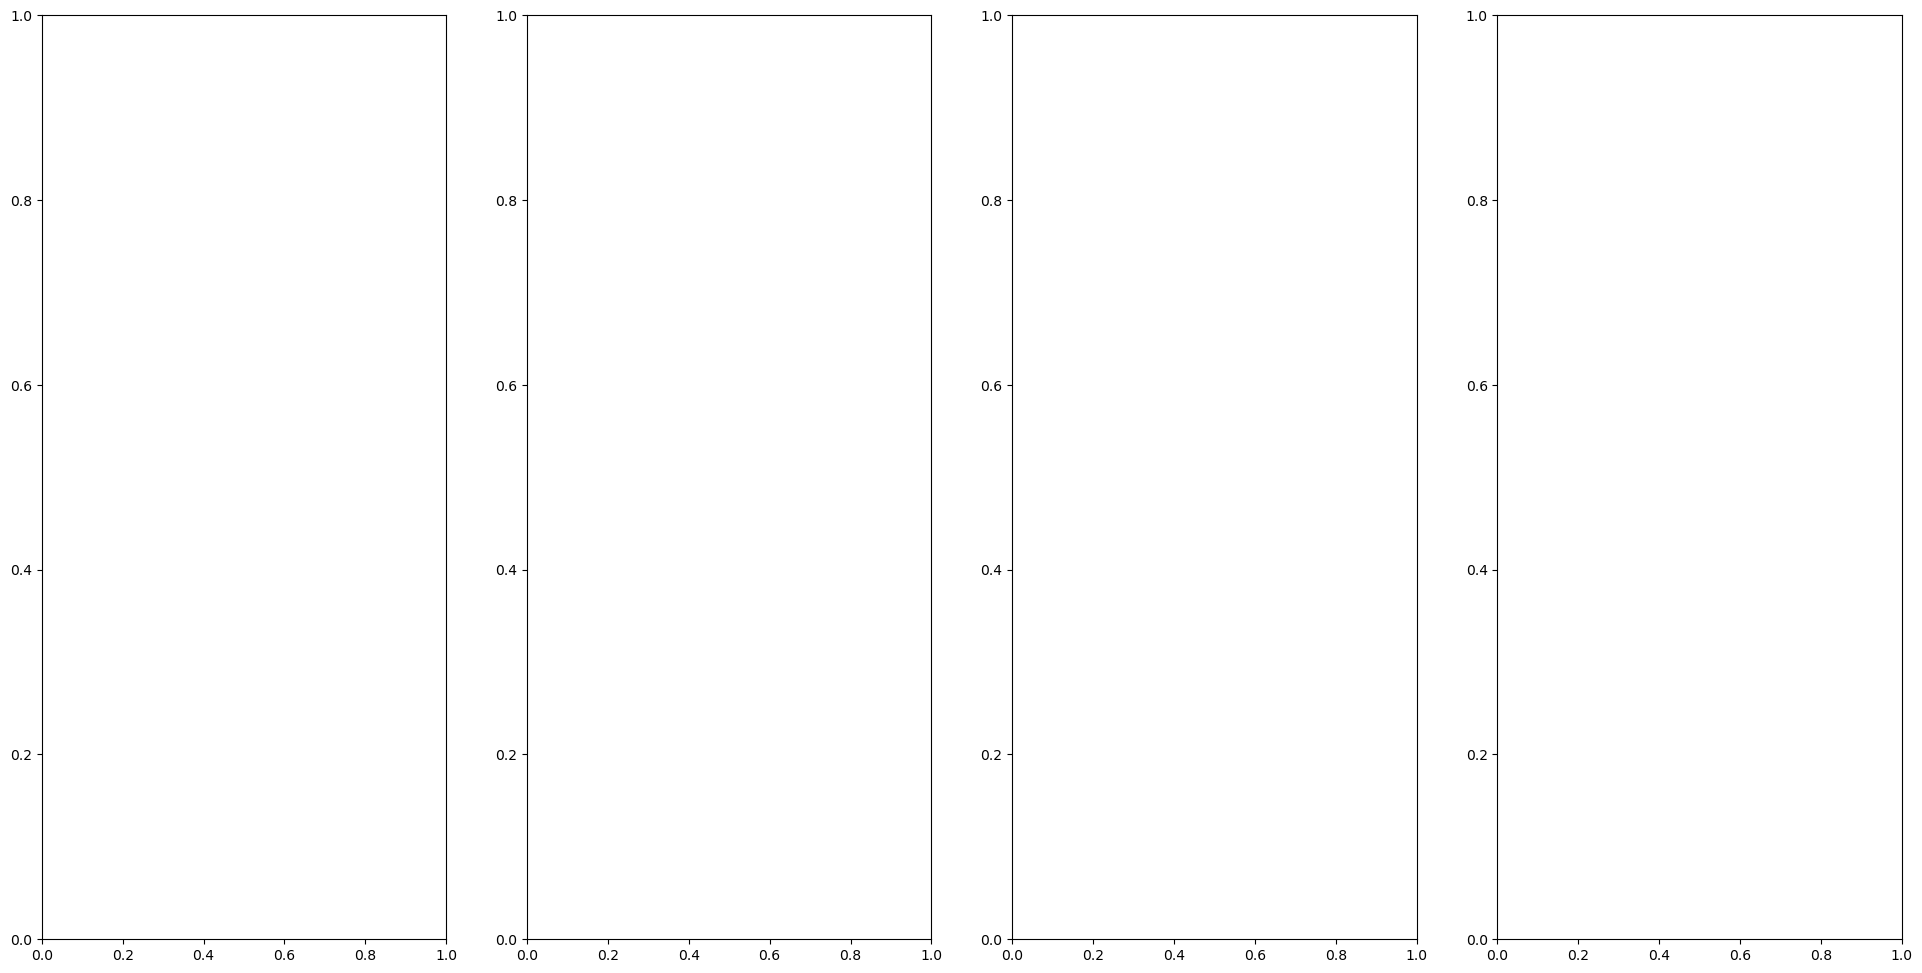

In [25]:
# 21. CNN2 Visualise Predictions

cnn2.load_state_dict(torch.load('H:/My Drive/Project/models/cnn2_best.pth',
                                 map_location=device))
cnn2.eval()

n_show = 4
shown  = 0

fig, axes = plt.subplots(1, n_show, figsize=(6 * n_show, 12))

with torch.no_grad():
    for batch in val_loader:
        images   = batch['image'].to(device)
        presence = batch['presence']
        coords   = batch['coords']
        subjects = batch['subject_id']

        coords_pred, _ = cnn2(images)
        coords_pred    = coords_pred.cpu()

        for i in range(len(subjects)):
            if shown >= n_show:
                break

            ax         = axes[shown]
            img        = images[i, 0].cpu().numpy()
            subject_id = subjects[i]

            ax.imshow(img, cmap='gray', aspect='auto')

            H, W = img.shape

            # denormalize coords from [-1,1] to pixel space
            def denorm(coords_norm, H, W):
                px = coords_norm.clone()
                px[:, :, 0] = (coords_norm[:, :, 0] + 1) * H / 2  # y
                px[:, :, 1] = (coords_norm[:, :, 1] + 1) * W / 2  # z
                return px

            pred_px = denorm(coords_pred[i], H, W)  # (25, 4, 2)
            gt_px   = denorm(coords[i],      H, W)  # (25, 4, 2)

            corner_colors = ['red', 'blue', 'green', 'yellow']

            for label in sorted(VERTEBRA_LABELS.keys()):
                idx      = LABEL_TO_IDX[label]
                present  = presence[i, idx].item()

                if present == 0:
                    continue

                # ground truth corners — white dots
                for c in range(NUM_CORNERS):
                    gy = gt_px[idx, c, 0].item()
                    gz = gt_px[idx, c, 1].item()
                    ax.plot(gz, gy, 'o', color='white', markersize=4, alpha=0.8)

                # predicted corners — coloured crosses
                for c in range(NUM_CORNERS):
                    py = pred_px[idx, c, 0].item()
                    pz = pred_px[idx, c, 1].item()
                    ax.plot(pz, py, 'x', color=corner_colors[c],
                            markersize=8, markeredgewidth=2)

                # draw predicted bounding box
                py_all = pred_px[idx, :, 0]
                pz_all = pred_px[idx, :, 1]
                y_min, y_max = py_all.min().item(), py_all.max().item()
                z_min, z_max = pz_all.min().item(), pz_all.max().item()
                rect = plt.Rectangle(
                    (z_min, y_min), z_max - z_min, y_max - y_min,
                    linewidth=1, edgecolor='cyan', facecolor='none', alpha=0.7
                )
                ax.add_patch(rect)

                # label
                name = VERTEBRA_LABELS[label]
                ax.text(z_min, y_min - 3, name,
                        color='cyan', fontsize=6, fontweight='bold')

            ax.set_title(f"{subject_id}", fontsize=9)
            ax.axis('off')
            shown += 1

        if shown >= n_show:
            break

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markersize=6, label='GT corners'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='red',
           markersize=8, label='Pred AS'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='blue',
           markersize=8, label='Pred PS'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='green',
           markersize=8, label='Pred AI'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='yellow',
           markersize=8, label='Pred PI'),
]
fig.legend(handles=legend, loc='lower center', ncol=5, fontsize=9)
plt.suptitle('CNN2 predictions vs ground truth (best epoch 31)', fontsize=12)
plt.tight_layout()
plt.show()

## 13. CNN3 — Single-Vertebra Crop Refinement

In [ ]:
# 22. VertebraCropDataset (coord-aware augmentation)
class VertebraCropDataset(Dataset):
    """
    Per-vertebra crop dataset for CNN3 refinement network.

    Takes whole-spine subjects, crops each present vertebra
    with padding, resizes to 512x512.

    Each item is one vertebra crop with:
    - image: (1, 512, 512) crop centered on vertebra
    - coords: (1, 4, 2) normalized corner coordinates
    """

    def __init__(self, data, image_size=(512, 512), augment=False, pad_factor=0.3):
        self.image_size = image_size
        self.augment    = augment
        self.pad_factor = pad_factor
        self.samples    = []

        for subject in data:
            img    = subject['image']
            orig_h, orig_w = img.shape

            for label, corner_data in subject['corners'].items():
                corners = corner_data['corners'].copy().astype(np.float32)

                y_min = corners[:, 0].min()
                y_max = corners[:, 0].max()
                z_min = corners[:, 1].min()
                z_max = corners[:, 1].max()

                h_pad = (y_max - y_min) * pad_factor
                w_pad = (z_max - z_min) * pad_factor

                y_min_pad = max(0,      int(y_min - h_pad))
                y_max_pad = min(orig_h, int(y_max + h_pad))
                z_min_pad = max(0,      int(z_min - w_pad))
                z_max_pad = min(orig_w, int(z_max + w_pad))

                self.samples.append({
                    'subject_id': subject['subject_id'],
                    'label':      label,
                    'name':       corner_data['name'],
                    'image':      img,
                    'corners':    corners,
                    'crop_box':   (y_min_pad, y_max_pad, z_min_pad, z_max_pad),
                })

    def __len__(self):
        return len(self.samples)

    def augment_with_coords(self, crop, corners_crop_px):
        """
        Apply geometric augmentation to crop image AND corner coordinates.
        corners_crop_px: (4, 2) in resized crop pixel space [y, z].
        """
        H, W    = crop.shape
        corners = corners_crop_px.copy()

        # 1. Horizontal flip (50%)
        if np.random.rand() > 0.5:
            crop           = np.fliplr(crop).copy()
            corners[:, 1]  = (W - 1) - corners[:, 1]

        # 2. Random rotation [-10, 10]
        angle  = np.random.uniform(-10, 10)
        cy, cz = H / 2.0, W / 2.0
        M = cv2.getRotationMatrix2D((cz, cy), angle, 1.0)
        crop = cv2.warpAffine(crop, M, (W, H),
                              flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT)
        # apply same rotation to corner coords
        pts      = np.column_stack([corners[:, 1], corners[:, 0], np.ones(4)])  # [z, y, 1]
        t        = (M @ pts.T).T                                                  # [z', y']
        corners  = np.column_stack([t[:, 1], t[:, 0]])                           # [y', z']

        # 3. Gaussian noise — image only
        crop = np.clip(crop + np.random.normal(0, 0.01, crop.shape).astype(np.float32), 0, 1)

        # 4. Brightness shift — image only
        crop = np.clip(crop * np.random.uniform(0.9, 1.1), 0, 1)

        return crop, corners

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        y1, y2, z1, z2 = sample['crop_box']

        # extract and normalise crop
        crop    = sample['image'][y1:y2, z1:z2].astype(np.float32)
        crop    = np.clip(crop, -1000, 2000)
        crop    = (crop - crop.min()) / (crop.max() - crop.min() + 1e-8)

        # shift corners to crop coordinate space
        corners_crop          = sample['corners'].copy()
        corners_crop[:, 0]   -= y1
        corners_crop[:, 1]   -= z1

        crop_h, crop_w = crop.shape

        # resize crop to 512x512
        crop_resized = cv2.resize(crop, (self.image_size[1], self.image_size[0]),
                                  interpolation=cv2.INTER_LINEAR)

        # scale corners to resized pixel space
        H_new, W_new = self.image_size
        corners_scaled          = corners_crop.copy()
        corners_scaled[:, 0]   *= H_new / crop_h
        corners_scaled[:, 1]   *= W_new / crop_w

        # augment image AND coords together
        if self.augment:
            crop_resized, corners_scaled = self.augment_with_coords(crop_resized, corners_scaled)

        # normalize to [-1, 1] for DSNT
        coords_norm          = np.zeros_like(corners_scaled)
        coords_norm[:, 0]    = (2 * corners_scaled[:, 0] + 1) / H_new - 1
        coords_norm[:, 1]    = (2 * corners_scaled[:, 1] + 1) / W_new - 1

        image_tensor  = torch.from_numpy(crop_resized).unsqueeze(0).float()     # (1, 512, 512)
        coords_tensor = torch.from_numpy(coords_norm).unsqueeze(0).float()       # (1, 4, 2)

        return {
            'image':      image_tensor,
            'coords':     coords_tensor,
            'subject_id': sample['subject_id'],
            'vertebra':   sample['name'],
        }


# create datasets
train_crop_dataset = VertebraCropDataset(training_data,   image_size=IMAGE_SIZE_STEP2, augment=True,  pad_factor=0.7)
val_crop_dataset   = VertebraCropDataset(validation_data, image_size=IMAGE_SIZE_STEP2, augment=False, pad_factor=0.7)
test_crop_dataset  = VertebraCropDataset(test_data,       image_size=IMAGE_SIZE_STEP2, augment=False, pad_factor=0.7)

# dataloaders
train_crop_loader = DataLoader(train_crop_dataset, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=0, pin_memory=PIN_MEMORY)
val_crop_loader   = DataLoader(val_crop_dataset,   batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)
test_crop_loader  = DataLoader(test_crop_dataset,  batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

# sanity check
sample = train_crop_dataset[0]
print(f"Crop dataset:")
print(f"  Train: {len(train_crop_dataset)} vertebra crops")
print(f"  Val:   {len(val_crop_dataset)} vertebra crops")
print(f"  Test:  {len(test_crop_dataset)} vertebra crops")
print(f"\nSample:")
print(f"  Image shape:  {sample['image'].shape}")
print(f"  Coords shape: {sample['coords'].shape}")
print(f"  Coords range: [{sample['coords'].min():.3f}, {sample['coords'].max():.3f}]")
print(f"  Subject:      {sample['subject_id']}")
print(f"  Vertebra:     {sample['vertebra']}")


# Cell 28b: Visualize crop dataset samples
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
row_labels = ['Train', 'Val', 'Test']
datasets   = [train_crop_dataset, val_crop_dataset, test_crop_dataset]

for row, (dataset, label) in enumerate(zip(datasets, row_labels)):
    indices = np.random.choice(len(dataset), size=6, replace=False)
    for col, idx in enumerate(indices):
        ax     = axes[row, col]
        s      = dataset[idx]
        img    = s['image'][0].numpy()
        coords = s['coords'][0].numpy()      # (4, 2) normalized

        ax.imshow(img, cmap='gray', aspect='auto')

        H, W = img.shape
        px_y = (coords[:, 0] + 1) * H / 2
        px_z = (coords[:, 1] + 1) * W / 2

        for c, (color, lbl) in enumerate(zip(['red','blue','green','yellow'],
                                              ['AS','PS','AI','PI'])):
            ax.scatter(px_z[c], px_y[c], color=color, s=80, marker='x', linewidths=2)

        ax.set_title(f"{s['vertebra']}\n{s['subject_id']}", fontsize=7)
        ax.axis('off')
    axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold')

corner_patches = [
    plt.Line2D([0],[0], marker='x', color='w', markerfacecolor=c,
               markeredgecolor=c, markersize=8, label=l)
    for c, l in zip(['red','blue','green','yellow'], ['Ant-Sup','Post-Sup','Ant-Inf','Post-Inf'])
]
fig.legend(handles=corner_patches, loc='lower center', ncol=4, fontsize=10)
plt.suptitle('VertebraCropDataset samples — Train / Val / Test', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 23. CNN3 Full Training — 200 epochs
import torch.optim as optim

cnn3 = CNN3(num_corners=NUM_CORNERS).to(device)

print('Training CNN3 — 200 epochs')
print('=' * 50)

history_cnn3 = train_cnn3(
    model        = cnn3,
    train_loader = train_crop_loader,
    val_loader   = val_crop_loader,
    num_epochs   = NUM_EPOCHS,
    lr           = LR_CNN3,
    save_path    = os.path.join(save_dir, 'cnn3_best.pth')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_cnn3['train_loss'], label='train')
ax.plot(history_cnn3['val_loss'],   label='val')
best_epoch = history_cnn3['val_loss'].index(min(history_cnn3['val_loss'])) + 1
ax.axvline(best_epoch - 1, color='red', linestyle='--', label=f'best (ep {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Euclidean Loss')
ax.set_title('CNN3 Training History')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best epoch: {best_epoch}/{NUM_EPOCHS}')
print(f'Best val loss: {min(history_cnn3["val_loss"]):.4f}')


In [ ]:
# 24. CNN3 Evaluation Metrics

cnn3.load_state_dict(torch.load(os.path.join(save_dir, 'cnn3_best.pth'), map_location=device))
cnn3.eval()

errors_x3 = {name: [] for name in TARGET_LABELS.values()}
errors_y3 = {name: [] for name in TARGET_LABELS.values()}

with torch.no_grad():
    for batch in val_crop_loader:
        images    = batch['image'].to(device)
        coords_gt = batch['coords'].numpy()
        names_b   = batch['vertebra']
        coords_pred, _ = cnn3(images)
        coords_pred = coords_pred.cpu().numpy()
        B = images.shape[0]
        H, W = IMAGE_SIZE_STEP2
        for b in range(B):
            name = names_b[b]
            pred = coords_pred[b, 0]
            gt   = coords_gt[b, 0]
            pred_px = np.stack([(pred[:, 0] + 1) * H / 2,
                                (pred[:, 1] + 1) * W / 2], axis=1)
            gt_px   = np.stack([(gt[:, 0]   + 1) * H / 2,
                                (gt[:, 1]   + 1) * W / 2], axis=1)
            vert_h = gt_px[:, 0].max() - gt_px[:, 0].min()
            vert_w = gt_px[:, 1].max() - gt_px[:, 1].min()
            if vert_h < 1 or vert_w < 1:
                continue
            for c in range(4):
                errors_y3[name].append(abs(pred_px[c, 0] - gt_px[c, 0]) / vert_h * 100)
                errors_x3[name].append(abs(pred_px[c, 1] - gt_px[c, 1]) / vert_w * 100)

print('CNN3 Validation — median % error per vertebra (should be lower than CNN2)')
print(f"{'Vertebra':<8} {'Med Err X%':>11} {'Med Err Y%':>11} {'N':>5}")
print('-' * 40)
lx3, ly3 = [], []
for name in ['T9','T10','T11','T12','L1','L2','L3','L4','L5']:
    ex = errors_x3.get(name, [])
    ey = errors_y3.get(name, [])
    if not ex:
        continue
    mx, my = np.median(ex), np.median(ey)
    flag = ' <- lumbar' if name in {'L1','L2','L3','L4','L5'} else ''
    print(f"{name:<8} {mx:>11.2f} {my:>11.2f} {len(ex)//4:>5}{flag}")
    lx3.extend(ex); ly3.extend(ey)
print('-' * 40)
if lx3:
    print(f"{'All (wt mean)':<8} {np.median(lx3):>11.2f} {np.median(ly3):>11.2f}")


In [ ]:
# 25. CNN3 Visualise Predictions

cnn3.load_state_dict(torch.load(os.path.join(save_dir, 'cnn3_best.pth'), map_location=device))
cnn3.eval()

n_show = 12
fig, axes = plt.subplots(2, 6, figsize=(24, 9))
axes = axes.flatten()
shown = 0
corner_colors = ['red', 'blue', 'green', 'yellow']
corner_labels = ['AS', 'PS', 'AI', 'PI']

with torch.no_grad():
    for batch in val_crop_loader:
        images    = batch['image'].to(device)
        coords_gt = batch['coords']
        names_b   = batch['vertebra']
        coords_pred, _ = cnn3(images)
        coords_pred = coords_pred.cpu()
        B = images.shape[0]
        H, W = IMAGE_SIZE_STEP2
        for b in range(B):
            if shown >= n_show:
                break
            ax   = axes[shown]
            img  = images[b, 0].cpu().numpy()
            pred = coords_pred[b, 0].numpy()
            gt   = coords_gt[b, 0].numpy()
            ax.imshow(img, cmap='gray')
            for c in range(4):
                gp = np.array([(gt[c, 0] + 1) * H / 2, (gt[c, 1] + 1) * W / 2])
                pp = np.array([(pred[c, 0] + 1) * H / 2, (pred[c, 1] + 1) * W / 2])
                ax.scatter(gp[1], gp[0], color=corner_colors[c], marker='o', s=60)
                ax.scatter(pp[1], pp[0], color=corner_colors[c], marker='x', s=80, linewidths=2)
                ax.plot([gp[1], pp[1]], [gp[0], pp[0]], color=corner_colors[c], lw=1, alpha=0.5)
            err = np.mean([np.linalg.norm(
                np.array([(pred[c,0]+1)*H/2, (pred[c,1]+1)*W/2]) -
                np.array([(gt[c,0]+1)*H/2,   (gt[c,1]+1)*W/2])) for c in range(4)])
            ax.set_title(f"{names_b[b]}  err={err:.1f}px", fontsize=8)
            ax.axis('off')
            shown += 1
        if shown >= n_show:
            break

plt.suptitle('CNN3 predictions — circle=GT  cross=pred  (val set)', fontsize=12)
plt.tight_layout()
plt.show()


## 14. Genant VCF Grading

In [ ]:
# 26. Orientation Check
subject = training_data[0]
img = subject['image']

fig, ax = plt.subplots(figsize=(4, 8))
ax.imshow(img, cmap='gray')
ax.set_title(f"{subject['subject_id']}")
plt.tight_layout()
plt.show()

In [ ]:
# 27. Genant VCF Grading
#
# Corner ordering in this dataset (from find_edge_corners / corners_rough):
#   corners[0] = AS  — closest to (y_min, z_min)  top-left
#   corners[1] = PS  — closest to (y_max, z_min)  bottom-left
#   corners[2] = AI  — closest to (y_min, z_max)  top-right
#   corners[3] = PI  — closest to (y_max, z_max)  bottom-right
#
# In the sagittal CT after rot90(k=1):
#   y increases downward  → y_min = superior end, y_max = inferior end
#   z increases rightward → z_min / z_max = one horizontal side
#
# Verify the anterior/posterior direction by inspecting the visualisation cell above.
# Adjust AS_IDX / AI_IDX if needed once orientation is confirmed.

AS_IDX, PS_IDX = 0, 1   # Superior corners (top, i.e. min-y side)
AI_IDX, PI_IDX = 2, 3   # Inferior corners (bottom, i.e. max-y side)
# Left column (z_min) = one side; right column (z_max) = other side.
# Label whichever is anterior in your images accordingly.


def corners_to_heights_px(corners_px, spacing_yz=None):
    """
    Compute anterior, middle, and posterior heights from 4 corner pixel coords.

    corners_px : (4, 2) array of [y, z] pixel coordinates in the original image.
    spacing_yz : (spacing_y, spacing_z) in mm/pixel; if supplied returns mm heights.

    Returns dict with keys: anterior_h, middle_h, posterior_h (pixels or mm).

    Corner convention:
        corners[0]=AS  corners[1]=PS  (superior row — min y)
        corners[2]=AI  corners[3]=PI  (inferior row — max y)
    The left column (z_min) pairs are AS/AI (one side),
    the right column (z_max) pairs are PS/PI (other side).
    """
    AS = corners_px[AS_IDX]
    PS = corners_px[PS_IDX]
    AI = corners_px[AI_IDX]
    PI = corners_px[PI_IDX]

    if spacing_yz is not None:
        sy, sz = spacing_yz
        def dist(a, b):
            return np.sqrt(((a[0]-b[0])*sy)**2 + ((a[1]-b[1])*sz)**2)
    else:
        def dist(a, b):
            return np.linalg.norm(a - b)

    h_left   = dist(AS, AI)              # height on AS/AI side
    h_right  = dist(PS, PI)              # height on PS/PI side
    mid_sup  = (AS + PS) / 2
    mid_inf  = (AI + PI) / 2
    h_middle = dist(mid_sup, mid_inf)    # height through midpoint

    return {'left': h_left, 'right': h_right, 'middle': h_middle}


def genant_grade(heights, ref_height=None):
    """
    Genant et al. (1993) semiquantitative grading.

    heights    : dict from corners_to_heights_px — keys 'left', 'right', 'middle'
    ref_height : reference posterior height (e.g. from a normal adjacent vertebra).
                 If None, uses the taller of left/right as the reference (self-reference).

    Returns:
        grade (int)  : 0=normal, 1=mild, 2=moderate, 3=severe
        reductions   : dict of % reduction for each height
        max_reduction: worst % reduction across the three heights
    """
    if ref_height is None:
        ref_height = max(heights['left'], heights['right'])

    if ref_height == 0:
        return 0, {'left': 0.0, 'right': 0.0, 'middle': 0.0}, 0.0

    reductions = {k: max(0.0, (ref_height - v) / ref_height) for k, v in heights.items()}
    max_red    = max(reductions.values())

    if max_red < 0.20:
        grade = 0   # Normal
    elif max_red < 0.25:
        grade = 1   # Mild (20-25%)
    elif max_red < 0.40:
        grade = 2   # Moderate (25-40%)
    else:
        grade = 3   # Severe (>40%)

    return grade, reductions, max_red


def classify_subject_vcf(subject, spacing_yz=None, use_adjacent_ref=True):
    """
    Run Genant grading for all L1-L5 vertebrae in a subject dict.

    subject        : one entry from training_data / test_data
    spacing_yz     : (sy, sz) pixel spacing in mm; None = pixel units
    use_adjacent_ref: use mean of adjacent vertebrae posterior heights as reference.
                      Falls back to self-reference if fewer than 2 neighbours.

    Returns list of dicts, one per lumbar vertebra present.
    """
    LUMBAR_NAMES = {'L1', 'L2', 'L3', 'L4', 'L5'}

    # collect lumbar vertebrae in superior→inferior order
    lumbar = []
    for label in sorted(subject['corners'].keys()):
        d = subject['corners'][label]
        if d['name'] in LUMBAR_NAMES:
            h = corners_to_heights_px(d['corners'], spacing_yz)
            lumbar.append({
                'name':    d['name'],
                'label':   label,
                'corners': d['corners'],
                'heights': h,
            })

    # compute reference heights
    results = []
    for i, v in enumerate(lumbar):
        if use_adjacent_ref:
            neighbours = []
            if i > 0:
                neighbours.append(max(lumbar[i-1]['heights']['left'],
                                      lumbar[i-1]['heights']['right']))
            if i < len(lumbar) - 1:
                neighbours.append(max(lumbar[i+1]['heights']['left'],
                                      lumbar[i+1]['heights']['right']))
            ref = np.mean(neighbours) if neighbours else None
        else:
            ref = None   # self-reference

        grade, reductions, max_red = genant_grade(v['heights'], ref_height=ref)
        results.append({
            'vertebra':     v['name'],
            'heights':      v['heights'],
            'ref_height':   ref,
            'reductions':   reductions,
            'max_reduction': max_red,
            'grade':        grade,
            'grade_label':  ['Normal', 'Mild', 'Moderate', 'Severe'][grade],
        })

    return results


# ---------- demo on training set ----------
print("Genant VCF grading demo — training subjects")
print("=" * 65)
print(f"{'Subject':<20} {'Vertebra':<8} {'Grade':<10} {'Max Red%':<10} {'Left':>7} {'Mid':>7} {'Right':>7}")
print("-" * 65)

for subject in training_data[:5]:
    sp = subject.get('spacing', None)
    sy_sz = (sp[2], sp[1]) if sp else None   # depends on sag_axis — adjust if needed
    results = classify_subject_vcf(subject, spacing_yz=sy_sz, use_adjacent_ref=True)
    for r in results:
        flag = ' *** FRACTURE' if r['grade'] >= 2 else (' *' if r['grade'] == 1 else '')
        print(f"{subject['subject_id']:<20} {r['vertebra']:<8} "
              f"{r['grade_label']:<10} {r['max_reduction']*100:>7.1f}%  "
              f"{r['heights']['left']:>6.1f} {r['heights']['middle']:>6.1f} "
              f"{r['heights']['right']:>6.1f}{flag}")
    print()

print("\nNote: heights are in pixels (or mm if spacing_yz is supplied).")
print("Verify anterior/posterior side labels by checking the visualisation cell above.")